# Statistical Validation — ROM Analyzer

Offline statistical validation of three kinematic models (Complete, C7, NOT_C7) across four anatomical distance conditions.

**Run all cells top-to-bottom to reproduce all results.**

## Section 0 — Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy.stats import shapiro
import warnings
import logging
from pathlib import Path

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

DATA_PATH  = Path(r'C:\Projects\Scripts_results_analysis_plots\Intermodel comparison\grab7\Standing\Mean_SD_comparison\Comparacion_Modelos_De pie.csv')
OUTPUT_DIR = Path(r'C:\Projects\Scripts_results_analysis_plots\Intermodel comparison\grab7\Standing\Mean_SD_comparison\results')
OUTPUT_DIR.mkdir(exist_ok=True)

# Raw values used in the CSV — do NOT change these
MODEL_CSV_NAMES = ['Complete', 'C7', 'NOT_C7']
ANAT_ORDER      = ['IJ_C7', 'PX_C7', 'IJ_PX_C7', 'Perfect']

# TFG display-name mapping: CSV value -> display name
MODEL_DISPLAY = {'Complete': 'Complete Model', 'C7': 'M1', 'NOT_C7': 'M2'}
# Reverse mapping: display name -> CSV value (used inside get_array)
MODEL_CSV     = {v: k for k, v in MODEL_DISPLAY.items()}

# Ordered list of display names used in iteration and output DataFrames
MODEL_ORDER = ['Complete Model', 'M1', 'M2']

MOVEMENTS_UNILATERAL = [
    'Shoulder Flex/Ext',
    'Shoulder Abd/Add',
    'Shoulder Int/Ext Rot',
    'Elbow Flex/Ext',
]
MOVEMENTS_BILATERAL = [
    'Trunk Extended Lateral Inclination',
    'Thorax Lateral Inclination',
]
MOVEMENT_LIST = MOVEMENTS_UNILATERAL + MOVEMENTS_BILATERAL

# Complete Model = gold-standard SULM (physical T8 + C7, no reconstruction).
# M1             = T8 virtual, C7 always physical.
# M2             = T8 virtual, C7 also virtual in dynamic trials.

ANGLE_VARS = ['Peak_deg', 'Valley_deg', 'ROM_deg']
VAR_LABELS = {
    'Peak_deg':   'Peak (deg)',
    'Valley_deg': 'Valley (deg)',
    'ROM_deg':    'ROM (deg)',
}

EXPECTED_COLUMNS = [
    'Movement', 'Model', 'Anatomic_Distances', 'Rep',
    'Left_Peak_frame', 'Left_Peak_time_s', 'Left_Peak_deg',
    'Left_Valley_frame', 'Left_Valley_time_s', 'Left_Valley_deg', 'Left_ROM_deg',
    'Right_Peak_frame', 'Right_Peak_time_s', 'Right_Peak_deg',
    'Right_Valley_frame', 'Right_Valley_time_s', 'Right_Valley_deg', 'Right_ROM_deg',
]


def get_sides(movement):
    return ['Left'] if movement in MOVEMENTS_BILATERAL else ['Left', 'Right']


def get_array(dataframe, movement, model, anat_dist, side, var):
    # Accepts display name ('M1', 'Complete Model') or CSV name; maps internally.
    csv_model = MODEL_CSV.get(model, model)
    col  = f'{side}_{var}'
    mask = (
        (dataframe['Movement']           == movement) &
        (dataframe['Model']              == csv_model) &
        (dataframe['Anatomic_Distances'] == anat_dist)
    )
    return dataframe[mask].sort_values('Rep')[col].to_numpy(dtype=float)


print('Configuration loaded.')


Configuration loaded.


## Section 1 — Data Loading and Validation

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df)} rows x {len(df.columns)} columns from {DATA_PATH.name}')

assert set(EXPECTED_COLUMNS) <= set(df.columns), \
    f'Missing columns: {set(EXPECTED_COLUMNS) - set(df.columns)}'
assert set(df['Model'].unique()) == set(MODEL_CSV_NAMES), \
    f'Unexpected Model values: {set(df["Model"].unique()) - set(MODEL_CSV_NAMES)}'
assert set(df['Anatomic_Distances'].unique()) == set(ANAT_ORDER), \
    f'Unexpected Anatomic_Distances: {set(df["Anatomic_Distances"].unique()) - set(ANAT_ORDER)}'
assert set(df['Movement'].unique()) == set(MOVEMENT_LIST), \
    f'Unexpected Movement: {set(df["Movement"].unique()) - set(MOVEMENT_LIST)}'

bilateral_mask = df['Movement'].isin(MOVEMENTS_BILATERAL)
for col in ['Right_Peak_deg', 'Right_Valley_deg', 'Right_ROM_deg']:
    assert df.loc[bilateral_mask, col].isna().all(), \
        f'{col} must be NaN for all bilateral rows'

unilateral_mask = ~bilateral_mask
for col in ['Left_ROM_deg', 'Right_ROM_deg']:
    assert not df.loc[unilateral_mask, col].isna().any(), \
        f'Unexpected NaNs in {col} for unilateral rows'

# Check: Elbow identity (Peak_deg identical across all model/anat combos)
elbow = df[df['Movement'] == 'Elbow Flex/Ext']
ref_pk = elbow[(elbow['Model'] == 'Complete') & (elbow['Anatomic_Distances'] == 'Perfect')] \
         .sort_values('Rep')['Left_Peak_deg'].to_numpy(dtype=float)
max_diff = 0.0
for m_csv in MODEL_CSV_NAMES:
    for a in ANAT_ORDER:
        arr = elbow[(elbow['Model'] == m_csv) & (elbow['Anatomic_Distances'] == a)] \
              .sort_values('Rep')['Left_Peak_deg'].to_numpy(dtype=float)
        n = min(len(ref_pk), len(arr))
        max_diff = max(max_diff, float(np.max(np.abs(arr[:n] - ref_pk[:n]))))
assert max_diff < 0.01, f'Elbow identity check failed: max diff = {max_diff:.4f} deg'
print(f'Elbow identity PASSED: max abs diff = {max_diff:.6f} deg (< 0.01 deg)')

# Check: ROM cancellation for Shoulder Flex/Ext (M1, IJ_C7 vs Perfect)
pk_perf = get_array(df, 'Shoulder Flex/Ext', 'M1', 'Perfect', 'Left', 'Peak_deg')
pk_ij   = get_array(df, 'Shoulder Flex/Ext', 'M1', 'IJ_C7',   'Left', 'Peak_deg')
rm_perf = get_array(df, 'Shoulder Flex/Ext', 'M1', 'Perfect', 'Left', 'ROM_deg')
rm_ij   = get_array(df, 'Shoulder Flex/Ext', 'M1', 'IJ_C7',   'Left', 'ROM_deg')
n = min(len(pk_perf), len(pk_ij))
peak_diff_mean = float(np.mean(np.abs(pk_ij[:n] - pk_perf[:n])))
rom_diff_mean  = float(np.mean(np.abs(rm_ij[:n] - rm_perf[:n])))
assert peak_diff_mean > 1.0, \
    f'Expected Peak offset > 1 deg for Shoulder Flex/Ext, got {peak_diff_mean:.3f}'
assert rom_diff_mean < 0.01, \
    f'Expected ROM diff ~0 for Shoulder Flex/Ext, got {rom_diff_mean:.3f}'
print(f'Cancellation PASSED: Peak offset = {peak_diff_mean:.2f} deg | ROM diff = {rom_diff_mean:.4f} deg')
print('All sanity checks passed.')


Loaded 516 rows x 18 columns from Comparacion_Modelos_De pie.csv
Elbow identity PASSED: max abs diff = 0.000000 deg (< 0.01 deg)
Cancellation PASSED: Peak offset = 3.30 deg | ROM diff = 0.0000 deg
All sanity checks passed.


### Key Finding: ROM Cancellation Effect

For most movements, the anatomic distance condition introduces a **uniform offset** on the thorax coordinate system: both Peak and Valley shift by the same amount and direction, so ROM (= Peak - Valley) remains unchanged even though the absolute angular values differ.

| Movement | Peak differs? | Valley differs? | ROM differs? |
|---|---|---|---|
| Shoulder Flex/Ext | YES (~3 deg) | YES (~3 deg, same sign) | **NO** — full cancellation |
| Shoulder Abd/Add | YES (small) | YES (opposite sign) | YES (partial) |
| Shoulder Int/Ext Rot | NO | NO | NO |
| Elbow Flex/Ext | NO | NO | NO (by construction) |
| Trunk Lat Incl | NO | NO | NO |
| Thorax Lat Incl | YES | YES (opposite sign) | YES (partial) |

**Consequence:** analysing only ROM underestimates the effect for Shoulder Flex/Ext. All three variables are analysed: `Peak_deg`, `Valley_deg`, and `ROM_deg`.

In [3]:
# Row counts as pivot (4 anat conditions as columns)
counts_df = df.copy()
counts_df['Model'] = counts_df['Model'].map(MODEL_DISPLAY)
counts = counts_df.groupby(['Model', 'Anatomic_Distances', 'Movement']).size().rename('n')
counts.unstack('Anatomic_Distances')


Anatomic_Distances                                 IJ_C7  IJ_PX_C7  PX_C7  \
Model          Movement                                                     
Complete Model Elbow Flex/Ext                          7         7      7   
               Shoulder Abd/Add                        7         7      7   
               Shoulder Flex/Ext                       7         7      7   
               Shoulder Int/Ext Rot                    6         6      6   
               Thorax Lateral Inclination              8         8      8   
               Trunk Extended Lateral Inclination      8         8      8   
M1             Elbow Flex/Ext                          7         7      7   
               Shoulder Abd/Add                        7         7      7   
               Shoulder Flex/Ext                       7         7      7   
               Shoulder Int/Ext Rot                    6         6      6   
               Thorax Lateral Inclination              8         8      8   
               Trunk Extended Lateral Inclination      8         8      8   
M2             Elbow Flex/Ext                          7         7      7   
               Shoulder Abd/Add                        7         7      7   
               Shoulder Flex/Ext                       7         7      7   
               Shoulder Int/Ext Rot                    6         6      6   
               Thorax Lateral Inclination              8         8      8   
               Trunk Extended Lateral Inclination      8         8      8   

Anatomic_Distances                                 Perfect  
Model          Movement                                     
Complete Model Elbow Flex/Ext                            7  
               Shoulder Abd/Add                          7  
               Shoulder Flex/Ext                         7  
               Shoulder Int/Ext Rot                      6  
               Thorax Lateral Inclination                8  
               Trunk Extended Lateral Inclination        8  
M1             Elbow Flex/Ext                            7  
               Shoulder Abd/Add                          7  
               Shoulder Flex/Ext                         7  
               Shoulder Int/Ext Rot                      6  
               Thorax Lateral Inclination                8  
               Trunk Extended Lateral Inclination        8  
M2             Elbow Flex/Ext                            7  
               Shoulder Abd/Add                          7  
               Shoulder Flex/Ext                         7  
               Shoulder Int/Ext Rot                      6  
               Thorax Lateral Inclination                8  
               Trunk Extended Lateral Inclination        8

## Section 2 — Statistical Helpers

In [4]:
def interpret_icc(value):
    # Koo & Li (2016) thresholds
    if value < 0.50: return 'poor'
    if value < 0.75: return 'moderate'
    if value < 0.90: return 'good'
    return 'excellent'


def compute_metrics(y_ref, y_alt, label_ref='ref', label_alt='alt'):
    # Compute Shapiro-Wilk, Bland-Altman, RMSD, ICC(C,1) between two paired arrays.
    # Returns None (logged warning) if n < 3.
    # Returns NaN ICC metrics if arrays have zero variance (e.g. Elbow ROM).
    # Sets shapiro_W/p = NaN and zero_variance = True when all differences are zero.
    n = len(y_ref)
    if n < 3:
        logging.warning(
            f'compute_metrics: n={n} < 3 for {label_ref} vs {label_alt}. Skipping.'
        )
        return None

    diff = y_alt - y_ref

    # Shapiro-Wilk: guard against zero-variance input (diff is constant)
    if np.var(diff) == 0.0:
        sw_stat       = float('nan')
        sw_p          = float('nan')
        zero_variance = True
    else:
        sw_stat, sw_p  = shapiro(diff)
        sw_stat        = float(sw_stat)
        sw_p           = float(sw_p)
        zero_variance  = False

    bias      = float(np.mean(diff))
    sd_diff   = float(np.std(diff, ddof=1))
    loa_upper = bias + 1.96 * sd_diff
    loa_lower = bias - 1.96 * sd_diff
    rmsd      = float(np.sqrt(np.mean(diff ** 2)))

    try:
        df_long = pd.DataFrame({
            'targets': list(range(n)) * 2,
            'raters':  [label_ref] * n + [label_alt] * n,
            'ratings': list(y_ref)  + list(y_alt),
        })
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            icc_res = pg.intraclass_corr(
                data=df_long, targets='targets', raters='raters', ratings='ratings'
            )
        icc_rows = icc_res[icc_res['Type'] == 'ICC(C,1)']
        if icc_rows.empty:
            raise ValueError('ICC(C,1) row not found')
        row     = icc_rows.iloc[0]
        icc_val = float(row['ICC'])
        ci_lo   = float(row['CI95'][0])
        ci_hi   = float(row['CI95'][1])
        if not (0 <= icc_val <= 1):
            raise ValueError(f'ICC out of range: {icc_val}')
        interp = interpret_icc(icc_val)
    except Exception:
        icc_val = ci_lo = ci_hi = float('nan')
        interp = 'n/a'

    return {
        'n_reps':             n,
        'bias_deg':           bias,
        'sd_diff_deg':        sd_diff,
        'loa_lower_deg':      loa_lower,
        'loa_upper_deg':      loa_upper,
        'rmsd_deg':           rmsd,
        'icc':                icc_val,
        'icc_ci95_lower':     ci_lo,
        'icc_ci95_upper':     ci_hi,
        'icc_interpretation': interp,
        'shapiro_W':          sw_stat,
        'shapiro_p':          sw_p,
        'zero_variance':      zero_variance,
    }


print('Helpers defined: interpret_icc, compute_metrics')


Helpers defined: interpret_icc, compute_metrics


## Section 3 — Comparison A: Effect of Anatomic Distance Condition

**Reference:** `(model, "Perfect")` for each reconstructed model.  
**Alternative:** `(model, anat_dist)` for each caliper-measured condition.  
Evaluated for all three angular variables: `Peak_deg`, `Valley_deg`, `ROM_deg`.

In [5]:
COL_ORDER_A = [
    'comparison', 'model', 'anat_dist', 'movement', 'side', 'angle_var',
    'n_reps', 'bias_deg', 'sd_diff_deg', 'loa_lower_deg', 'loa_upper_deg',
    'rmsd_deg', 'icc', 'icc_ci95_lower', 'icc_ci95_upper', 'icc_interpretation',
    'shapiro_W', 'shapiro_p', 'zero_variance',
]

results_A = []
for model in ['M1', 'M2']:
    for movement in MOVEMENT_LIST:
        for side in get_sides(movement):
            for var in ANGLE_VARS:
                y_ref = get_array(df, movement, model, 'Perfect', side, var)
                for anat_dist in ['IJ_C7', 'PX_C7', 'IJ_PX_C7']:
                    y_alt = get_array(df, movement, model, anat_dist, side, var)
                    n = min(len(y_ref), len(y_alt))
                    m = compute_metrics(
                        y_ref[:n], y_alt[:n],
                        label_ref=f'{model}_Perfect_{var}',
                        label_alt=f'{model}_{anat_dist}_{var}',
                    )
                    if m is None:
                        continue
                    results_A.append({
                        'comparison': 'A',
                        'model':      model,
                        'anat_dist':  anat_dist,
                        'movement':   movement,
                        'side':       side,
                        'angle_var':  var,
                        **m,
                    })

df_A = pd.DataFrame(results_A)[COL_ORDER_A]
print(f'Comparison A: {len(df_A)} rows ({len(df_A)//3} per angle_var)')
zv_A = df_A['zero_variance'].sum()
print(f'  zero_variance=True: {zv_A} rows')


Comparison A: 180 rows (60 per angle_var)
  zero_variance=True: 106 rows


### Results — ROM_deg

For movements with full cancellation (Shoulder Flex/Ext), RMSD is near zero. **This is not an error** — it reflects the coordinate offset cancelling out in Peak-Valley subtraction. See the Peak_deg table below for the real magnitude.

In [6]:
df_A[df_A['angle_var'] == 'ROM_deg'].drop(columns='comparison').reset_index(drop=True)


,model,anat_dist,movement,side,angle_var,n_reps,bias_deg,sd_diff_deg,loa_lower_deg,loa_upper_deg,rmsd_deg,icc,icc_ci95_lower,icc_ci95_upper,icc_interpretation,shapiro_W,shapiro_p,zero_variance
0,M1,IJ_C7,Shoulder Flex/Ext,Left,ROM_deg,7,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.00,1.0,excellent,NaN,NaN,True
1,M1,PX_C7,Shoulder Flex/Ext,Left,ROM_deg,7,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.00,1.0,excellent,NaN,NaN,True
2,M1,IJ_PX_C7,Shoulder Flex/Ext,Left,ROM_deg,7,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.00,1.0,excellent,NaN,NaN,True
3,M1,IJ_C7,Shoulder Flex/Ext,Right,ROM_deg,7,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,excellent,NaN,NaN,True
4,M1,PX_C7,Shoulder Flex/Ext,Right,ROM_deg,7,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,excellent,NaN,NaN,True
5,M1,IJ_PX_C7,Shoulder Flex/Ext,Right,ROM_deg,7,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,excellent,NaN,NaN,True
6,M1,IJ_C7,Shoulder Abd/Add,Left,ROM_deg,7,-0.275714,0.075467,-0.423629,-0.127799,0.284429,0.999653,1.00,1.0,excellent,0.936821,0.610272,False
7,M1,PX_C7,Shoulder Abd/Add,Left,ROM_deg,7,-0.171429,0.047409,-0.264350,-0.078507,0.176958,0.999864,1.00,1.0,excellent,0.915252,0.433431,False
8,M1,IJ_PX_C7,Shoulder Abd/Add,Left,ROM_deg,7,-0.224286,0.061606,-0.345033,-0.103539,0.231424,0.999769,1.00,1.0,excellent,0.942822,0.664259,False
9,M1,IJ_C7,Shoulder Abd/Add,Right,ROM_deg,7,-0.364286,0.069488,-0.500482,-0.228089,0.369923,0.999883,1.00,1.0,excellent,0.948470,0.715757,False


### Results — Peak_deg

Contrast with ROM_deg: Shoulder Flex/Ext now shows substantial bias, revealing the true offset hidden by ROM cancellation.

In [7]:
df_A[df_A['angle_var'] == 'Peak_deg'].drop(columns='comparison').reset_index(drop=True)


,model,anat_dist,movement,side,angle_var,n_reps,bias_deg,sd_diff_deg,loa_lower_deg,loa_upper_deg,rmsd_deg,icc,icc_ci95_lower,icc_ci95_upper,icc_interpretation,shapiro_W,shapiro_p,zero_variance
0,M1,IJ_C7,Shoulder Flex/Ext,Left,Peak_deg,7,-3.301429,3.779645e-03,-3.308837,-3.294020,3.301430,0.999997,1.00,1.0,excellent,0.452971,0.000004,False
1,M1,PX_C7,Shoulder Flex/Ext,Left,Peak_deg,7,-2.028571,3.779645e-03,-2.035980,-2.021163,2.028574,0.999997,1.00,1.0,excellent,0.452971,0.000004,False
2,M1,IJ_PX_C7,Shoulder Flex/Ext,Left,Peak_deg,7,-2.668571,3.779645e-03,-2.675980,-2.661163,2.668574,0.999997,1.00,1.0,excellent,0.452971,0.000004,False
3,M1,IJ_C7,Shoulder Flex/Ext,Right,Peak_deg,7,-3.304286,5.345225e-03,-3.314762,-3.293809,3.304289,0.999989,1.00,1.0,excellent,0.664436,0.001497,False
4,M1,PX_C7,Shoulder Flex/Ext,Right,Peak_deg,7,-2.030000,0.000000e+00,-2.030000,-2.030000,2.030000,1.000000,1.00,1.0,excellent,NaN,NaN,True
5,M1,IJ_PX_C7,Shoulder Flex/Ext,Right,Peak_deg,7,-2.670000,1.386905e-14,-2.670000,-2.670000,2.670000,NaN,NaN,NaN,n/a,0.600399,0.000275,False
6,M1,IJ_C7,Shoulder Abd/Add,Left,Peak_deg,7,-0.080000,3.415650e-02,-0.146947,-0.013053,0.086023,0.999532,1.00,1.0,excellent,0.962301,0.838217,False
7,M1,PX_C7,Shoulder Abd/Add,Left,Peak_deg,7,-0.048571,1.864454e-02,-0.085115,-0.012028,0.051547,0.999859,1.00,1.0,excellent,0.964775,0.858502,False
8,M1,IJ_PX_C7,Shoulder Abd/Add,Left,Peak_deg,7,-0.062857,2.811541e-02,-0.117963,-0.007751,0.068034,0.999681,1.00,1.0,excellent,0.974731,0.930276,False
9,M1,IJ_C7,Shoulder Abd/Add,Right,Peak_deg,7,-0.254286,4.429339e-02,-0.341101,-0.167471,0.257571,0.999724,1.00,1.0,excellent,0.955790,0.781909,False


### Results — Valley_deg

In [8]:
df_A[df_A['angle_var'] == 'Valley_deg'].drop(columns='comparison').reset_index(drop=True)


,model,anat_dist,movement,side,angle_var,n_reps,bias_deg,sd_diff_deg,loa_lower_deg,loa_upper_deg,rmsd_deg,icc,icc_ci95_lower,icc_ci95_upper,icc_interpretation,shapiro_W,shapiro_p,zero_variance
0,M1,IJ_C7,Shoulder Flex/Ext,Left,Valley_deg,7,-3.301429,3.779645e-03,-3.308837,-3.294020,3.301430,0.999999,1.00,1.0,excellent,0.452971,0.000004,False
1,M1,PX_C7,Shoulder Flex/Ext,Left,Valley_deg,7,-2.027143,4.879500e-03,-2.036707,-2.017579,2.027148,0.999998,1.00,1.0,excellent,0.600399,0.000275,False
2,M1,IJ_PX_C7,Shoulder Flex/Ext,Left,Valley_deg,7,-2.664286,5.345225e-03,-2.674762,-2.653809,2.664290,0.999998,1.00,1.0,excellent,0.664436,0.001497,False
3,M1,IJ_C7,Shoulder Flex/Ext,Right,Valley_deg,7,-3.302857,4.879500e-03,-3.312421,-3.293293,3.302860,0.999998,1.00,1.0,excellent,0.600399,0.000275,False
4,M1,PX_C7,Shoulder Flex/Ext,Right,Valley_deg,7,-2.030000,2.689094e-15,-2.030000,-2.030000,2.030000,1.000000,1.00,1.0,excellent,0.452971,0.000004,False
5,M1,IJ_PX_C7,Shoulder Flex/Ext,Right,Valley_deg,7,-2.668571,3.779645e-03,-2.675980,-2.661163,2.668574,0.999999,1.00,1.0,excellent,0.452971,0.000004,False
6,M1,IJ_C7,Shoulder Abd/Add,Left,Valley_deg,7,0.194286,5.287001e-02,0.090660,0.297911,0.200357,0.999832,1.00,1.0,excellent,0.946679,0.699408,False
7,M1,PX_C7,Shoulder Abd/Add,Left,Valley_deg,7,0.125714,3.359422e-02,0.059870,0.191559,0.129505,0.999933,1.00,1.0,excellent,0.942926,0.665200,False
8,M1,IJ_PX_C7,Shoulder Abd/Add,Left,Valley_deg,7,0.161429,4.598136e-02,0.071305,0.251552,0.166947,0.999873,1.00,1.0,excellent,0.938302,0.623478,False
9,M1,IJ_C7,Shoulder Abd/Add,Right,Valley_deg,7,0.111429,6.414270e-02,-0.014291,0.237148,0.126265,0.999844,1.00,1.0,excellent,0.907673,0.379997,False


## Section 4 — Comparison B.1: Effect of Kinematic Model (Perfect distances)

**Reference:** `("Complete Model", "Perfect")` — gold-standard.
**Alternative:** `(model, "Perfect")` for model in `["M1", "M2"]`.
Evaluated for all three angular variables: `Peak_deg`, `Valley_deg`, `ROM_deg`.

In [9]:
COL_ORDER_B = [
    'comparison', 'model', 'movement', 'side', 'angle_var',
    'n_reps', 'bias_deg', 'sd_diff_deg', 'loa_lower_deg', 'loa_upper_deg',
    'rmsd_deg', 'icc', 'icc_ci95_lower', 'icc_ci95_upper', 'icc_interpretation',
    'shapiro_W', 'shapiro_p', 'zero_variance',
]

results_B1 = []
for model in ['M1', 'M2']:
    for movement in MOVEMENT_LIST:
        for side in get_sides(movement):
            for var in ANGLE_VARS:
                y_ref = get_array(df, movement, 'Complete Model', 'Perfect', side, var)
                y_alt = get_array(df, movement, model,            'Perfect', side, var)
                n = min(len(y_ref), len(y_alt))
                m = compute_metrics(y_ref[:n], y_alt[:n],
                                    label_ref='Complete Model', label_alt=model)
                if m is None:
                    continue
                results_B1.append({
                    'comparison': 'B.1',
                    'model':      model,
                    'movement':   movement,
                    'side':       side,
                    'angle_var':  var,
                    **m,
                })

df_B1 = pd.DataFrame(results_B1)[COL_ORDER_B]
print(f'Comparison B.1: {len(df_B1)} rows')
zv_B1 = df_B1['zero_variance'].sum()
print(f'  zero_variance=True: {zv_B1} rows')
df_B1.drop(columns='comparison').reset_index(drop=True)


Comparison B.1: 60 rows
  zero_variance=True: 12 rows


,model,movement,side,angle_var,n_reps,bias_deg,sd_diff_deg,loa_lower_deg,loa_upper_deg,rmsd_deg,icc,icc_ci95_lower,icc_ci95_upper,icc_interpretation,shapiro_W,shapiro_p,zero_variance
0,M1,Shoulder Flex/Ext,Left,Peak_deg,7,-0.467143,0.519285,-1.484942,0.550656,0.670341,0.955743,0.77,0.99,excellent,0.936413,0.606656,False
1,M1,Shoulder Flex/Ext,Left,Valley_deg,7,-0.175714,0.342143,-0.846315,0.494886,0.362235,0.991450,0.95,1.00,excellent,0.822835,0.068373,False
2,M1,Shoulder Flex/Ext,Left,ROM_deg,7,-0.288571,0.526670,-1.320844,0.743701,0.566594,0.989142,0.94,1.00,excellent,0.858019,0.145317,False
3,M1,Shoulder Flex/Ext,Right,Peak_deg,7,-1.525714,0.318217,-2.149419,-0.902009,1.553898,0.965903,0.82,0.99,excellent,0.796373,0.037709,False
4,M1,Shoulder Flex/Ext,Right,Valley_deg,7,0.945714,0.258319,0.439410,1.452019,0.975485,0.995574,0.97,1.00,excellent,0.975417,0.934480,False
5,M1,Shoulder Flex/Ext,Right,ROM_deg,7,-2.471429,0.329820,-3.117875,-1.824982,2.490221,0.995691,0.98,1.00,excellent,0.969922,0.897884,False
6,M1,Shoulder Abd/Add,Left,Peak_deg,7,4.908571,1.428839,2.108047,7.709096,5.083699,0.033253,-0.69,0.72,poor,0.693336,0.003134,False
7,M1,Shoulder Abd/Add,Left,Valley_deg,7,-0.182857,0.416842,-0.999867,0.634153,0.427050,0.989100,0.94,1.00,excellent,0.950882,0.737724,False
8,M1,Shoulder Abd/Add,Left,ROM_deg,7,5.091429,1.566838,2.020426,8.162431,5.294045,0.840161,0.33,0.97,good,0.824576,0.071049,False
9,M1,Shoulder Abd/Add,Right,Peak_deg,7,4.048571,0.674819,2.725926,5.371217,4.096493,0.925082,0.63,0.99,excellent,0.817478,0.060720,False


## Section 5 — Comparison B.2: Sensitivity Analysis — Real Anthropometric Distances

**Reference:** `("Complete Model", "Perfect")` — gold-standard (same as Comparison B.1).
Complete Model data is identical across all anatomic distance conditions, so `Perfect` is used as its reference condition for consistency.

**Alternative:** `(model, "IJ_PX_C7")` for model in `["M1", "M2"]`.
`IJ_PX_C7` uses real caliper-measured distances (IJ + PX + C7 landmarks) and represents the most realistic clinical scenario where the static T8 marker is not available.

This is a **sensitivity analysis** of Comparison B.1: it quantifies how much the model-vs-gold-standard agreement changes when real (caliper-measured) distances replace the ideal `Perfect` condition.

Evaluated for all three angular variables: `Peak_deg`, `Valley_deg`, `ROM_deg`.

In [10]:
results_B2 = []
for model in ['M1', 'M2']:
    for movement in MOVEMENT_LIST:
        for side in get_sides(movement):
            for var in ANGLE_VARS:
                y_ref = get_array(df, movement, 'Complete Model', 'Perfect',  side, var)
                y_alt = get_array(df, movement, model,            'IJ_PX_C7', side, var)
                n = min(len(y_ref), len(y_alt))
                m = compute_metrics(y_ref[:n], y_alt[:n],
                                    label_ref='Complete Model', label_alt=model)
                if m is None:
                    continue
                results_B2.append({
                    'comparison': 'B.2',
                    'model':      model,
                    'movement':   movement,
                    'side':       side,
                    'angle_var':  var,
                    **m,
                })

df_B2 = pd.DataFrame(results_B2)[COL_ORDER_B]
print(f'Comparison B.2: {len(df_B2)} rows')
zv_B2 = df_B2['zero_variance'].sum()
print(f'  zero_variance=True: {zv_B2} rows')
df_B2.drop(columns='comparison').reset_index(drop=True)


Comparison B.2: 60 rows
  zero_variance=True: 12 rows


,model,movement,side,angle_var,n_reps,bias_deg,sd_diff_deg,loa_lower_deg,loa_upper_deg,rmsd_deg,icc,icc_ci95_lower,icc_ci95_upper,icc_interpretation,shapiro_W,shapiro_p,zero_variance
0,M1,Shoulder Flex/Ext,Left,Peak_deg,7,-3.135714,0.522043,-4.158918,-2.112511,3.172743,0.955206,0.76,0.99,excellent,0.935952,0.602569,False
1,M1,Shoulder Flex/Ext,Left,Valley_deg,7,-2.840000,0.345543,-3.517264,-2.162736,2.857961,0.991287,0.95,1.00,excellent,0.826497,0.074113,False
2,M1,Shoulder Flex/Ext,Left,ROM_deg,7,-0.288571,0.526670,-1.320844,0.743701,0.566594,0.989142,0.94,1.00,excellent,0.858019,0.145317,False
3,M1,Shoulder Flex/Ext,Right,Peak_deg,7,-4.195714,0.318217,-4.819419,-3.572009,4.206045,0.965903,0.82,0.99,excellent,0.796373,0.037709,False
4,M1,Shoulder Flex/Ext,Right,Valley_deg,7,-1.722857,0.259340,-2.231163,-1.214551,1.739507,0.995538,0.97,1.00,excellent,0.977159,0.944647,False
5,M1,Shoulder Flex/Ext,Right,ROM_deg,7,-2.471429,0.329820,-3.117875,-1.824982,2.490221,0.995691,0.98,1.00,excellent,0.969922,0.897884,False
6,M1,Shoulder Abd/Add,Left,Peak_deg,7,4.845714,1.449573,2.004551,7.686877,5.028124,0.033416,-0.69,0.72,poor,0.689638,0.002854,False
7,M1,Shoulder Abd/Add,Left,Valley_deg,7,-0.021429,0.398222,-0.801944,0.759087,0.369304,0.989896,0.94,1.00,excellent,0.928348,0.536942,False
8,M1,Shoulder Abd/Add,Left,ROM_deg,7,4.867143,1.596431,1.738139,7.996147,5.086608,0.832234,0.30,0.97,good,0.814515,0.056838,False
9,M1,Shoulder Abd/Add,Right,Peak_deg,7,3.847143,0.691248,2.492297,5.201989,3.900009,0.922917,0.62,0.99,excellent,0.833929,0.087161,False


## Section 6 — Visualizations

In [11]:
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

MODEL_COLORS = {'M1': '#2E86C1', 'M2': '#E74C3C'}
ANAT_COLORS  = {'IJ_C7': '#8E44AD', 'PX_C7': '#E67E22', 'IJ_PX_C7': '#27AE60'}
ANAT_CONDITIONS = ['IJ_C7', 'PX_C7', 'IJ_PX_C7']


### 6.1 — RMSD Heatmap Grid (Comparison A)

One figure per model: 1x3 grid (Peak / Valley / ROM), shared color scale. The cancellation effect is visually obvious: ROM heatmap is near-white for Shoulder Flex/Ext while Peak and Valley show substantial RMSD.

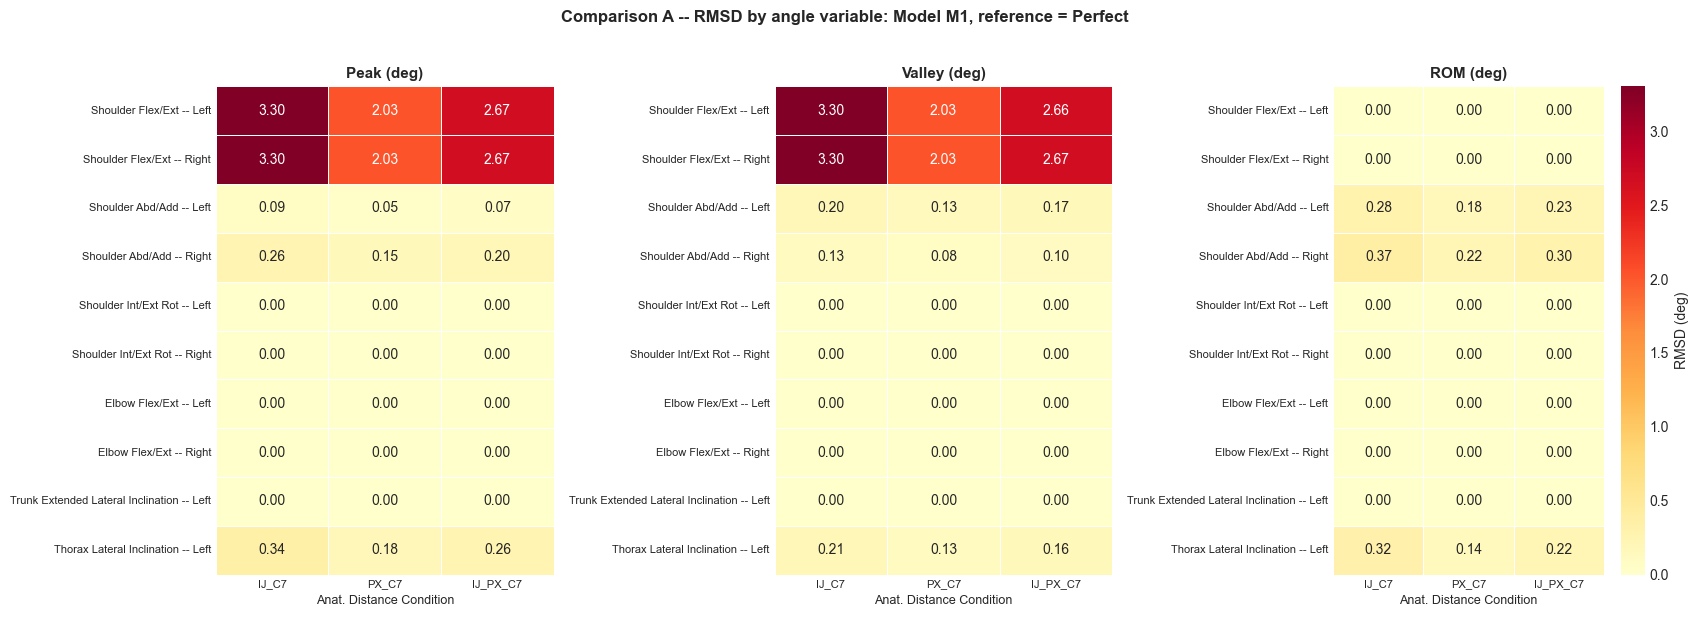

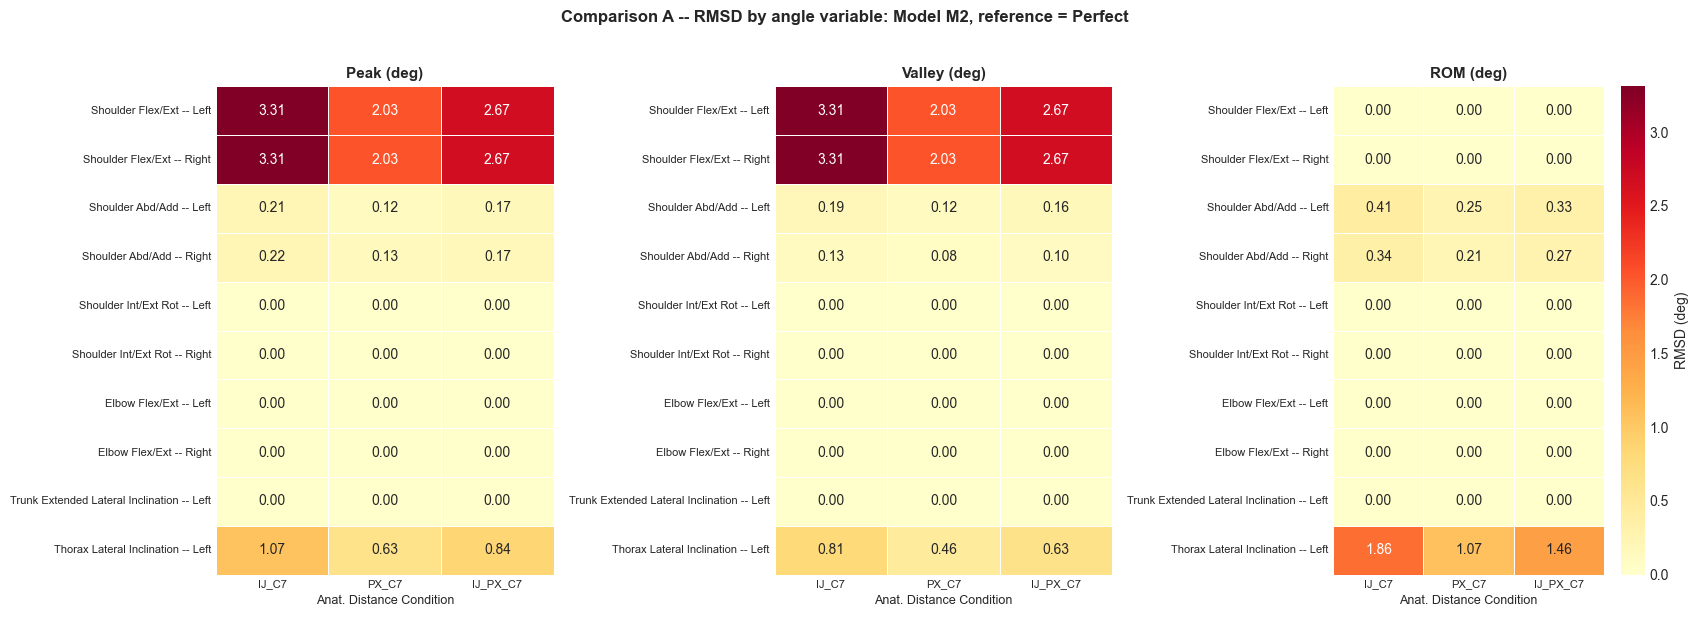

In [12]:
for model in ['M1', 'M2']:
    sub = df_A[df_A['model'] == model].copy()
    sub['row_label'] = sub['movement'] + ' -- ' + sub['side']
    ordered_rows = [
        f'{mv} -- {sd}'
        for mv in MOVEMENT_LIST for sd in get_sides(mv)
    ]
    vmax = float(sub['rmsd_deg'].dropna().max()) or 1.0

    fig, axes = plt.subplots(1, 3, figsize=(17, max(5, len(ordered_rows) * 0.6)))
    fig.suptitle(
        f'Comparison A -- RMSD by angle variable: Model {model}, reference = Perfect',
        fontsize=12, fontweight='bold', y=1.02,
    )
    for ax, var in zip(axes, ANGLE_VARS):
        pivot = sub[sub['angle_var'] == var].pivot_table(
            index='row_label', columns='anat_dist', values='rmsd_deg'
        )[['IJ_C7', 'PX_C7', 'IJ_PX_C7']]
        pivot = pivot.reindex([r for r in ordered_rows if r in pivot.index])
        sns.heatmap(
            pivot.astype(float), ax=ax,
            cmap='YlOrRd', annot=True, fmt='.2f',
            vmin=0, vmax=vmax,
            linewidths=0.4,
            cbar=(var == 'ROM_deg'),
            cbar_kws={'label': 'RMSD (deg)'} if var == 'ROM_deg' else {},
        )
        ax.set_title(VAR_LABELS[var], fontsize=11, fontweight='bold')
        ax.set_xlabel('Anat. Distance Condition', fontsize=9)
        ax.set_ylabel('')
        ax.tick_params(axis='y', rotation=0, labelsize=8)
        ax.tick_params(axis='x', labelsize=8)
    plt.tight_layout()
    plt.show()


### 6.2 — Bland-Altman Plots (Comparison A)

One figure per (model, movement, side, angle_var) — 1x3 subplots per anat_dist condition.

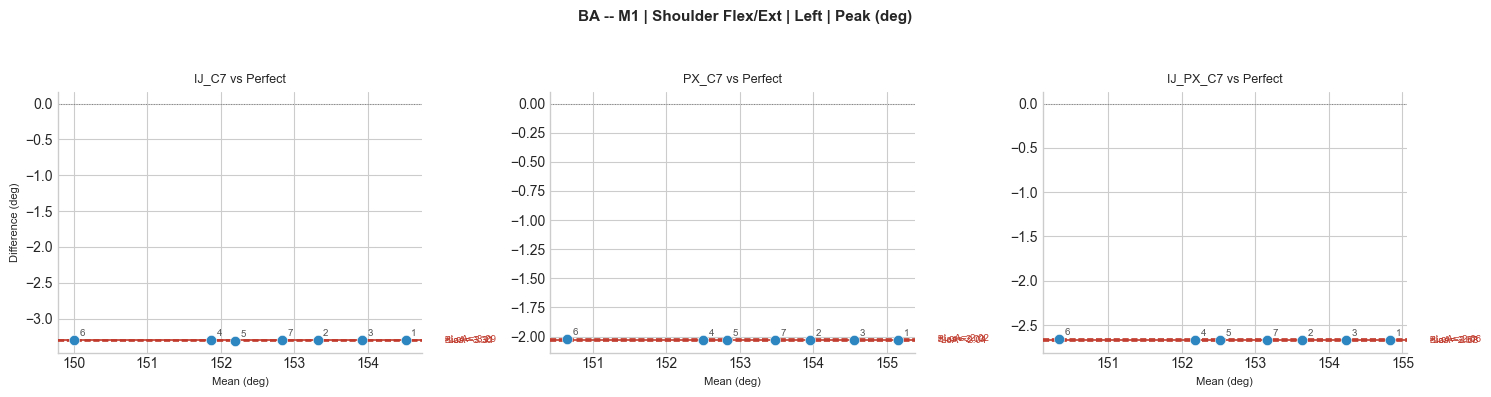

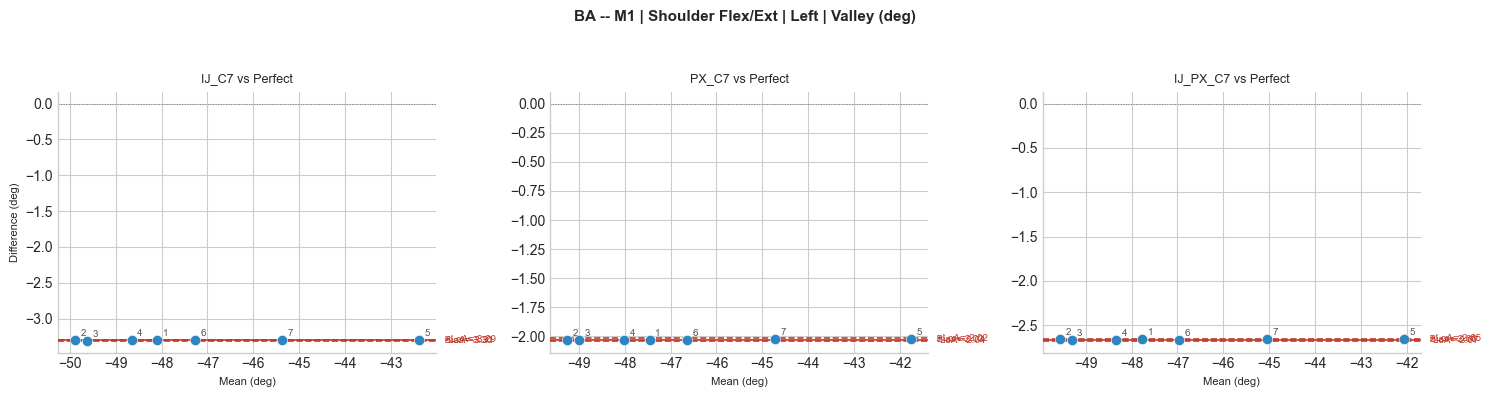

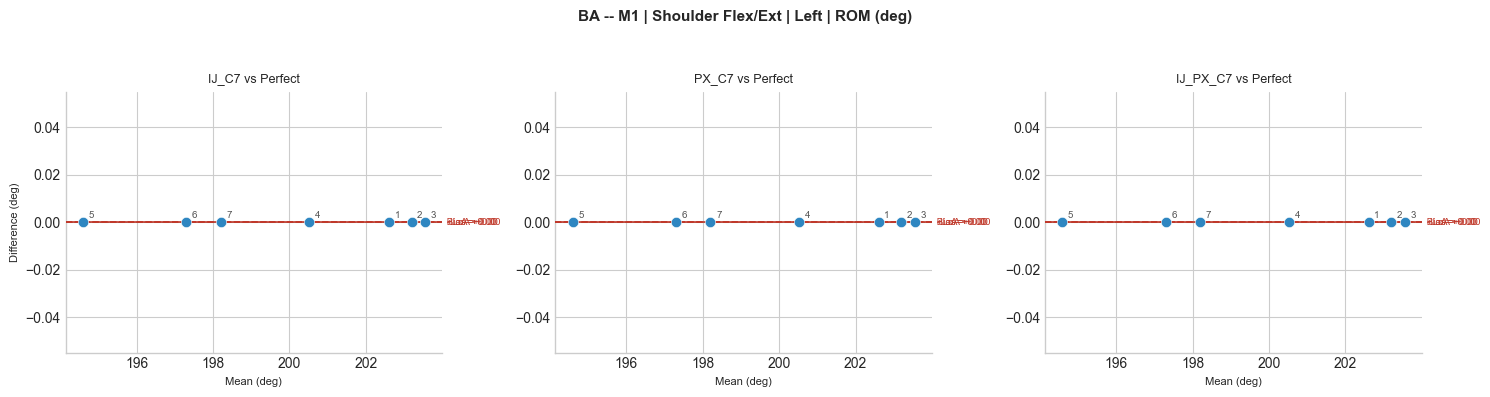

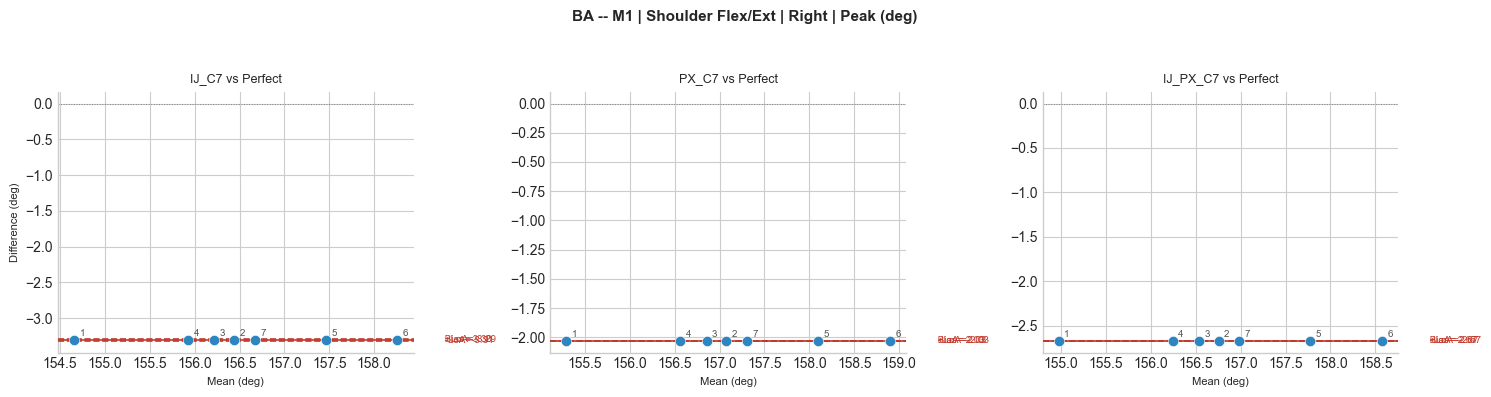

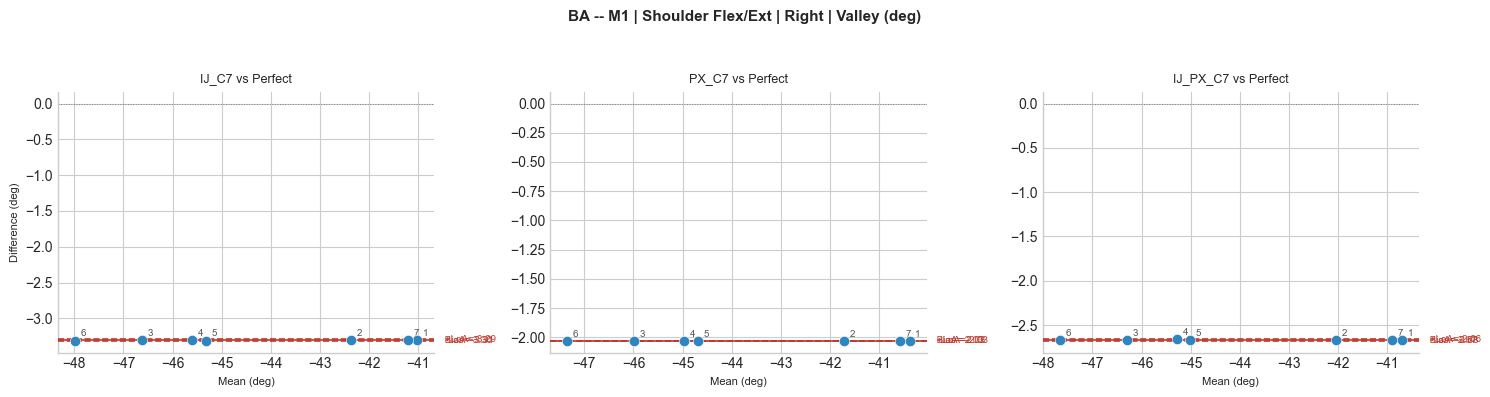

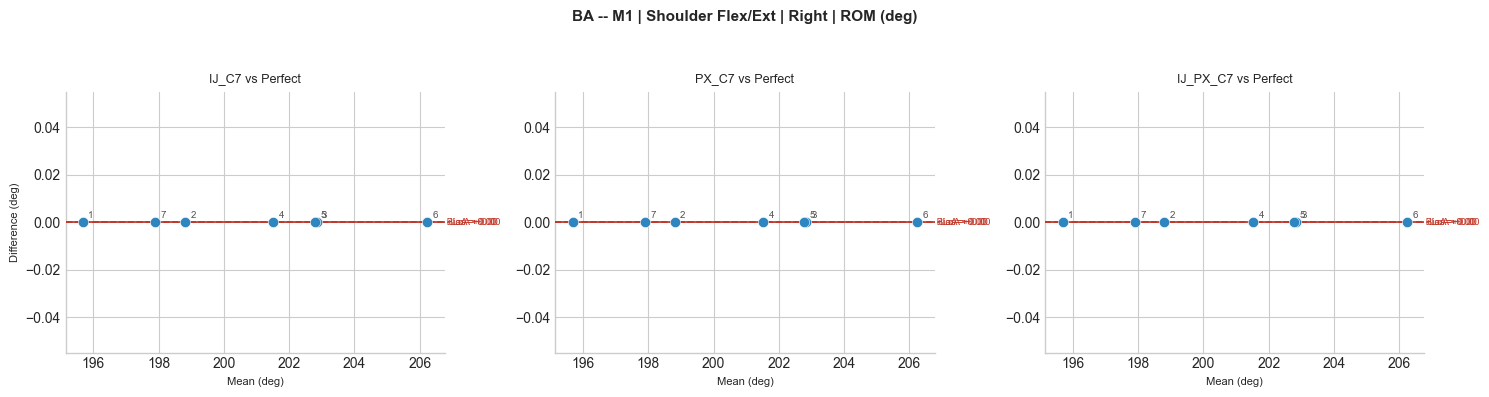

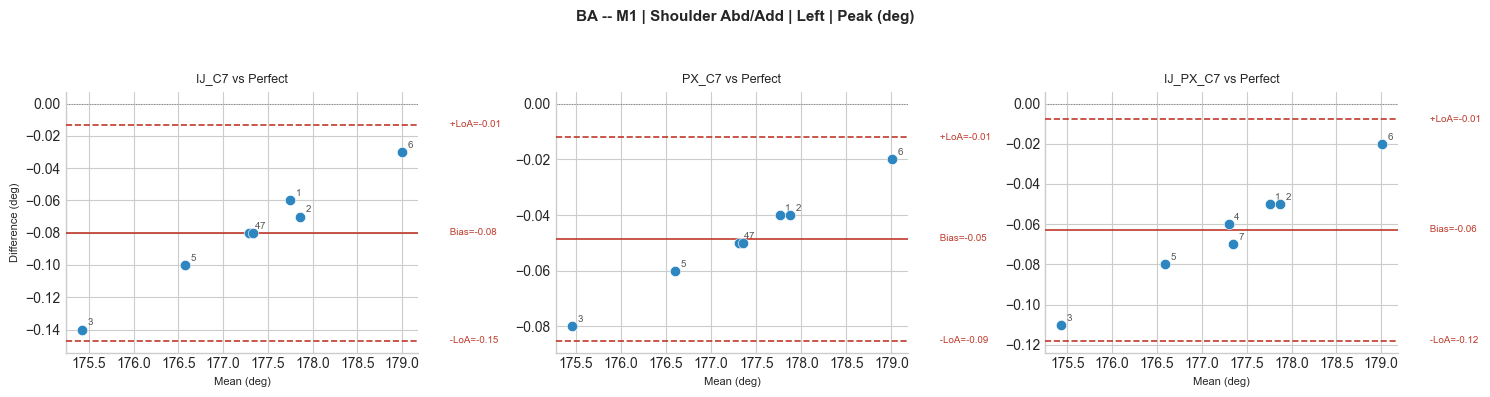

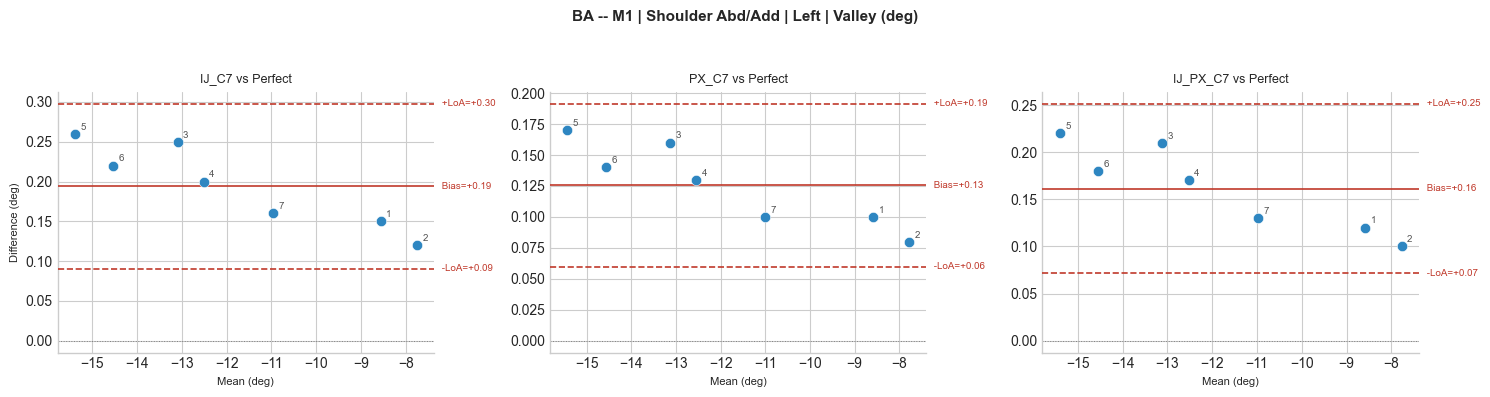

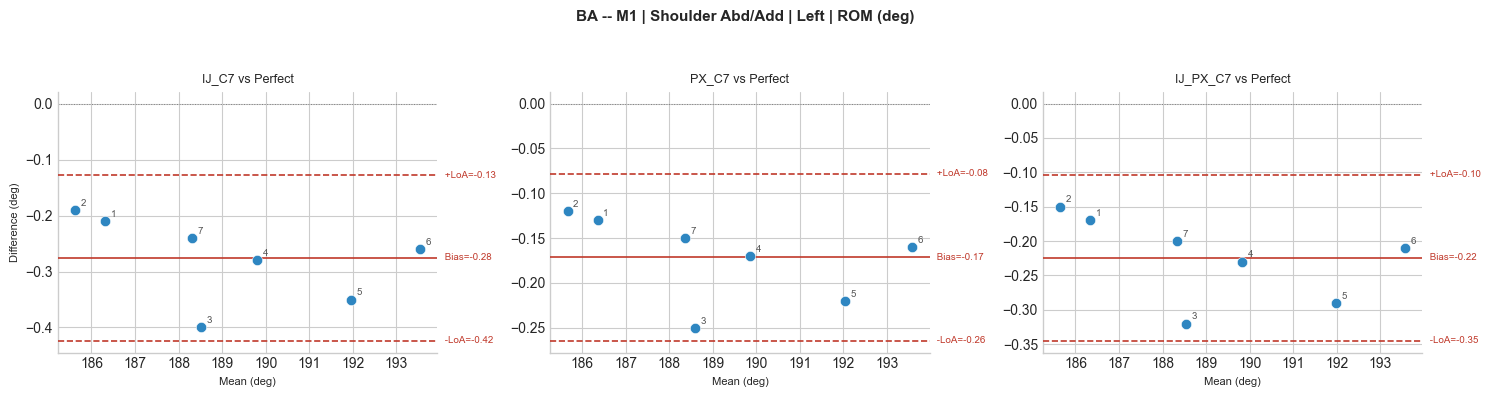

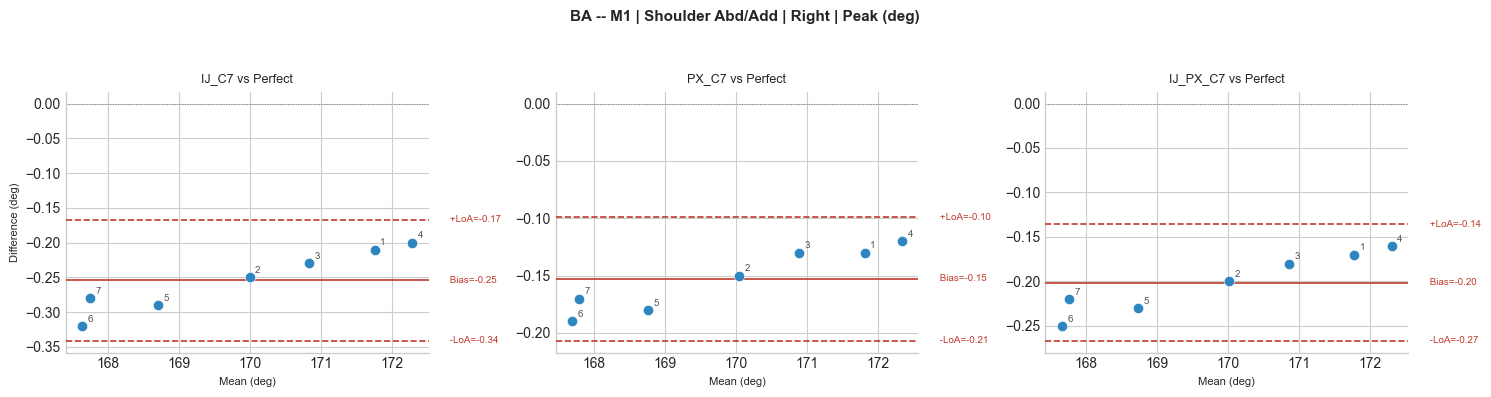

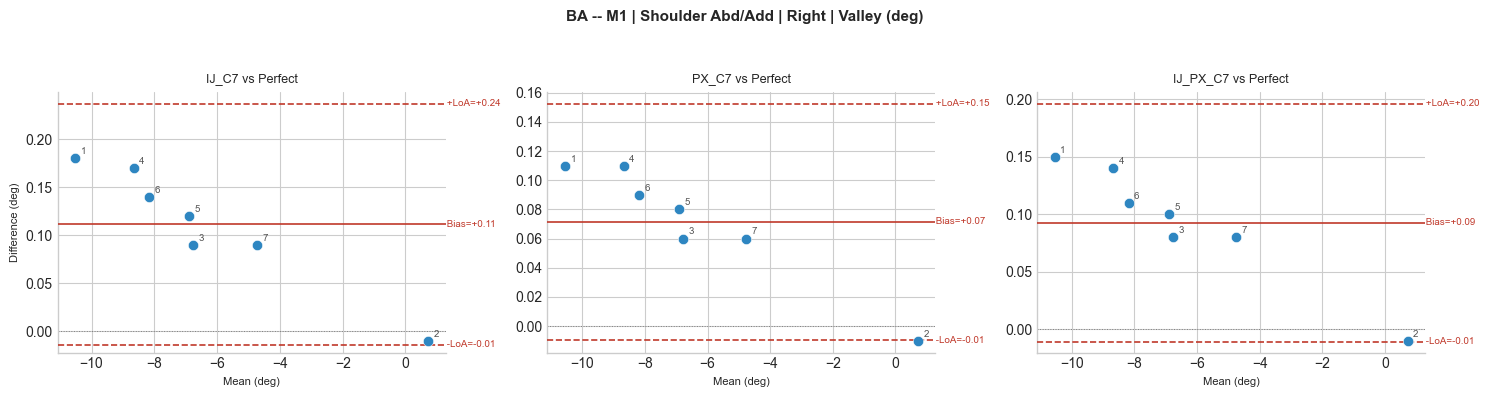

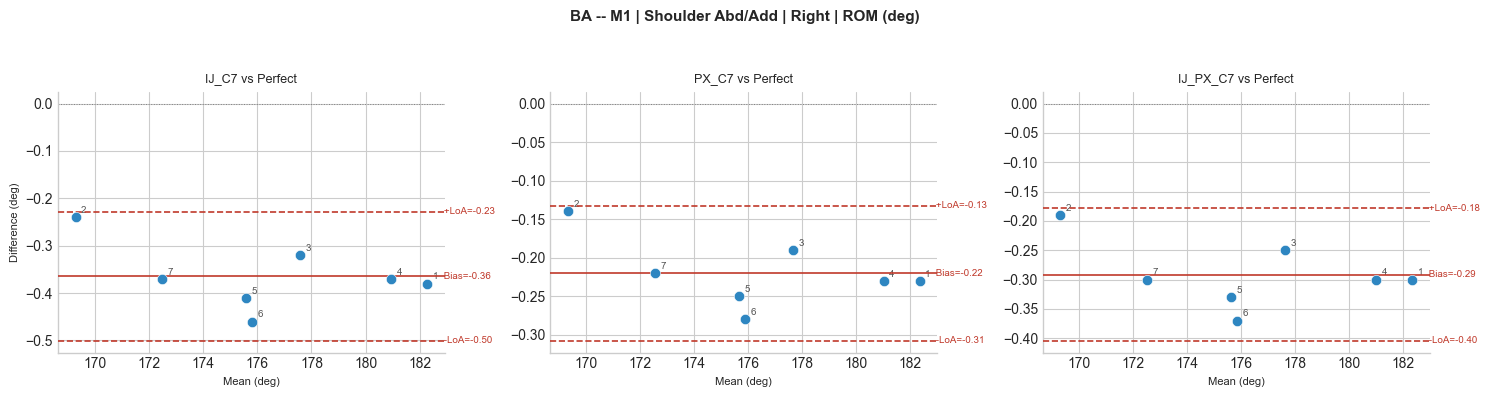

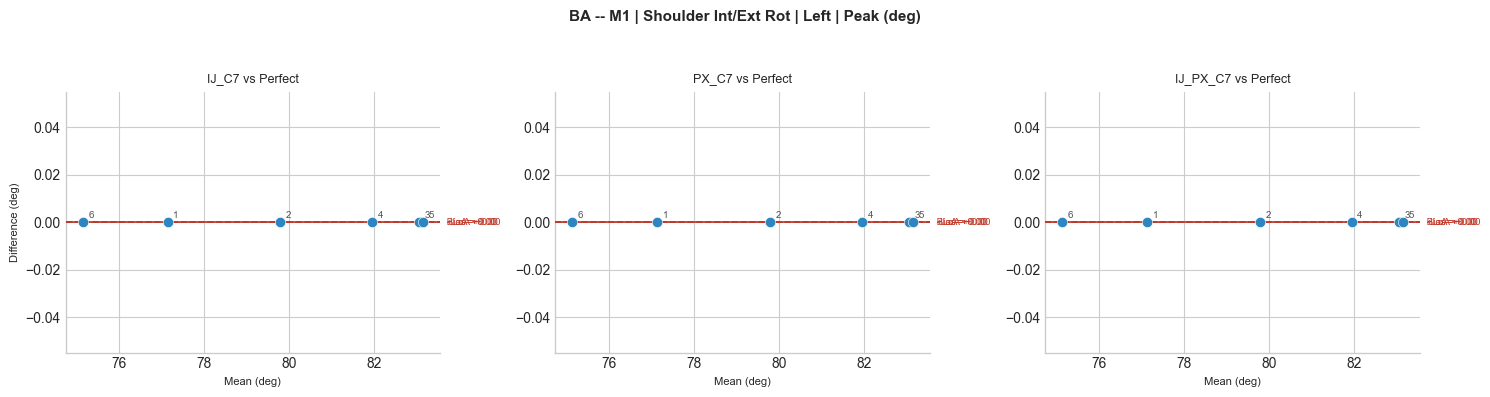

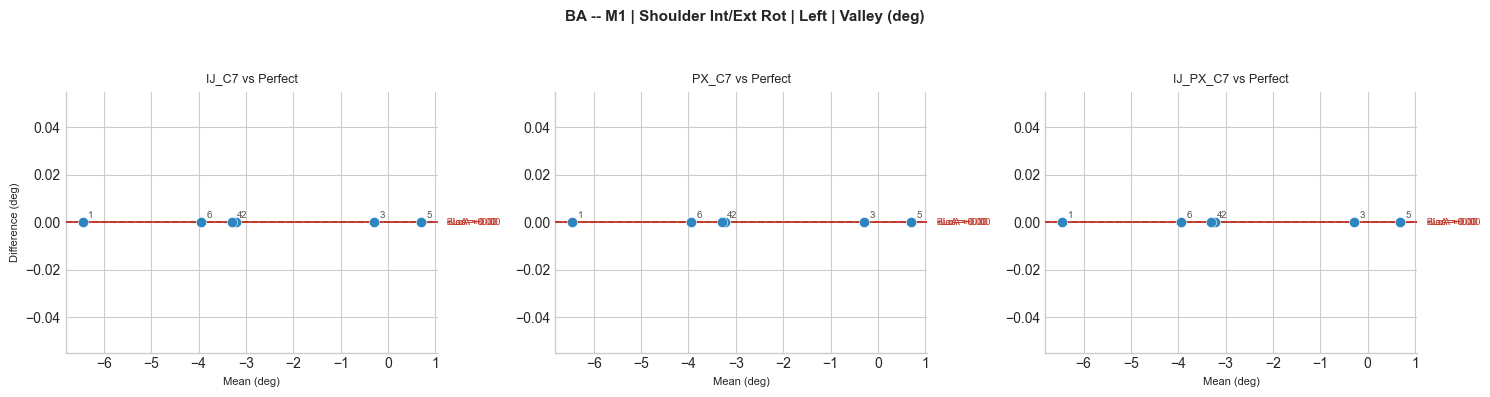

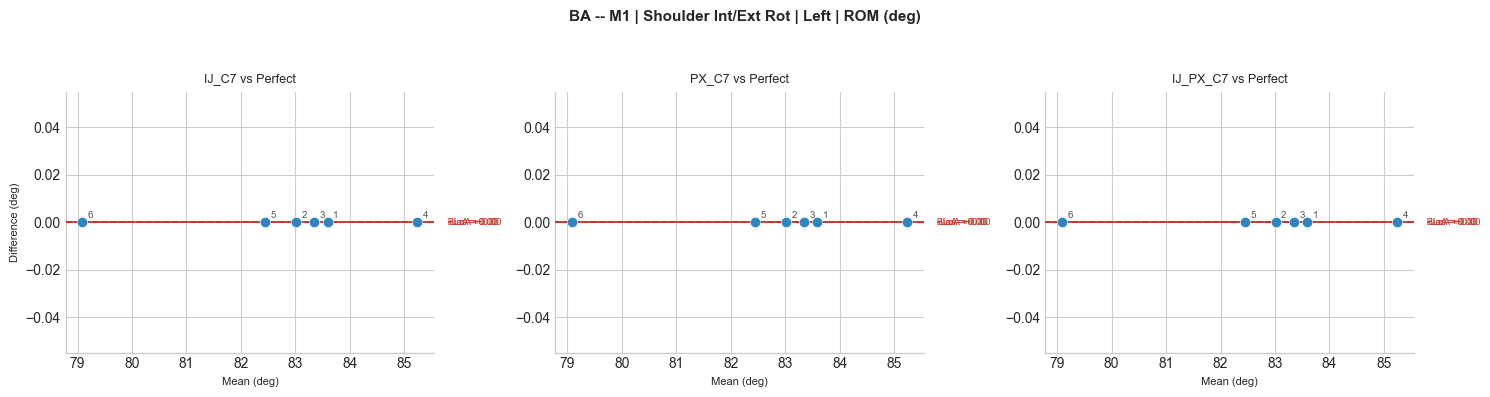

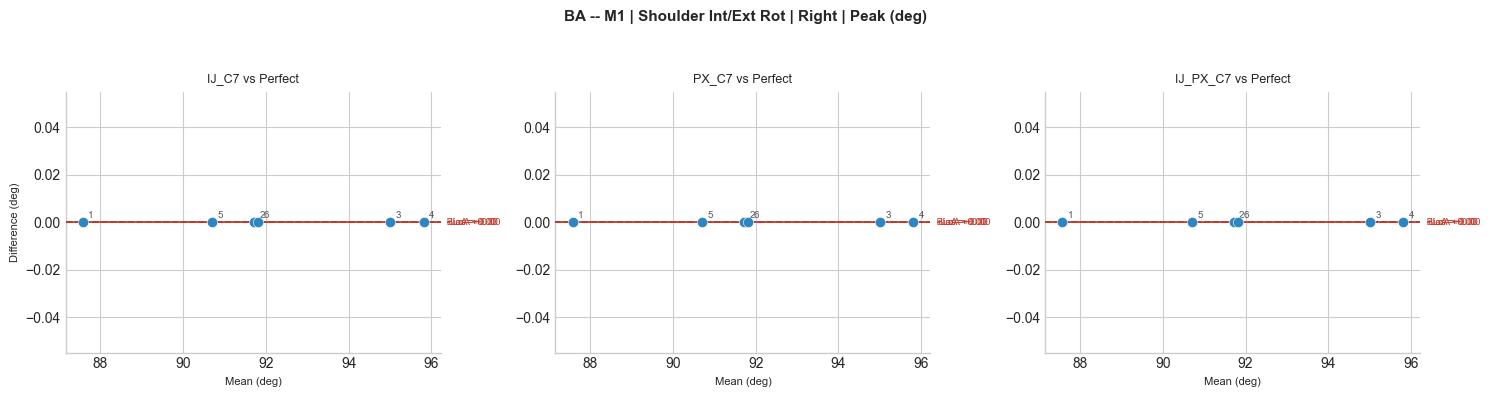

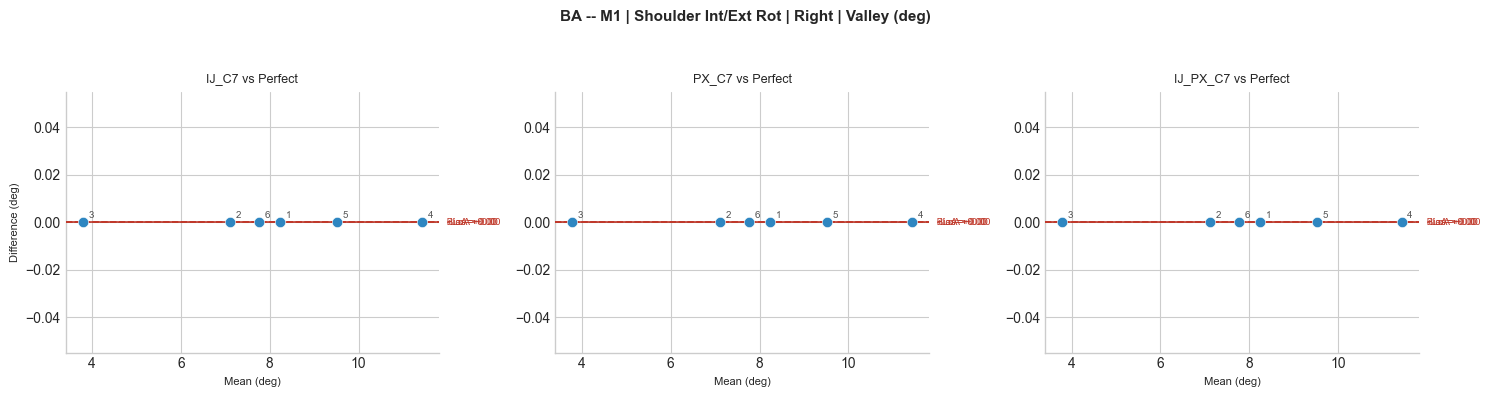

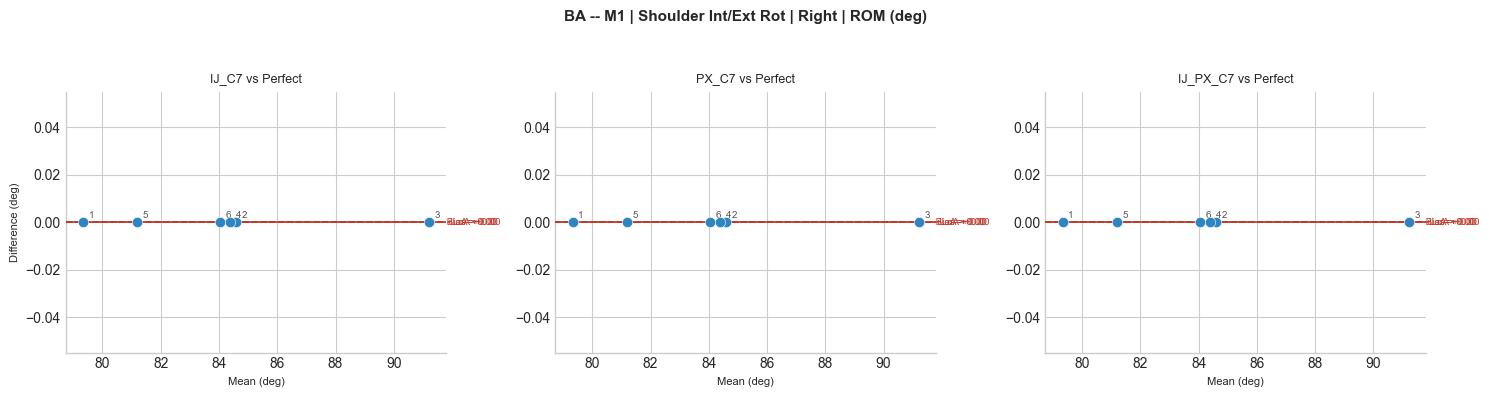

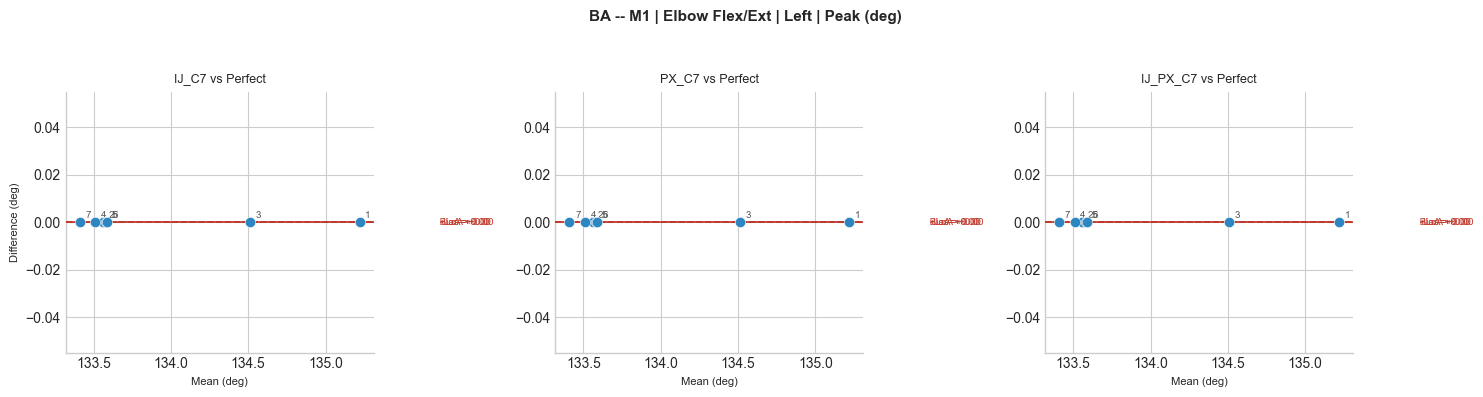

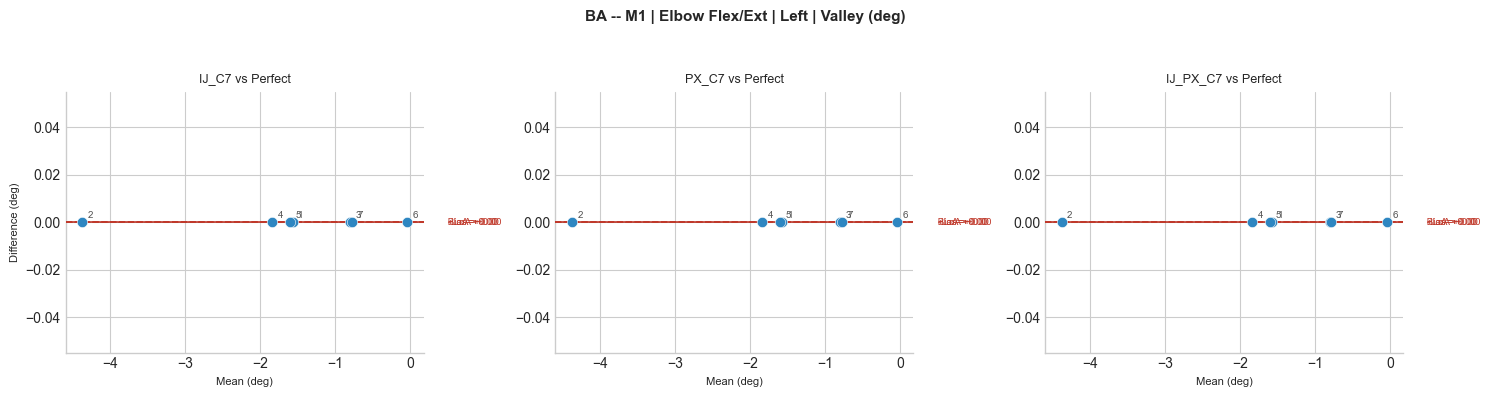

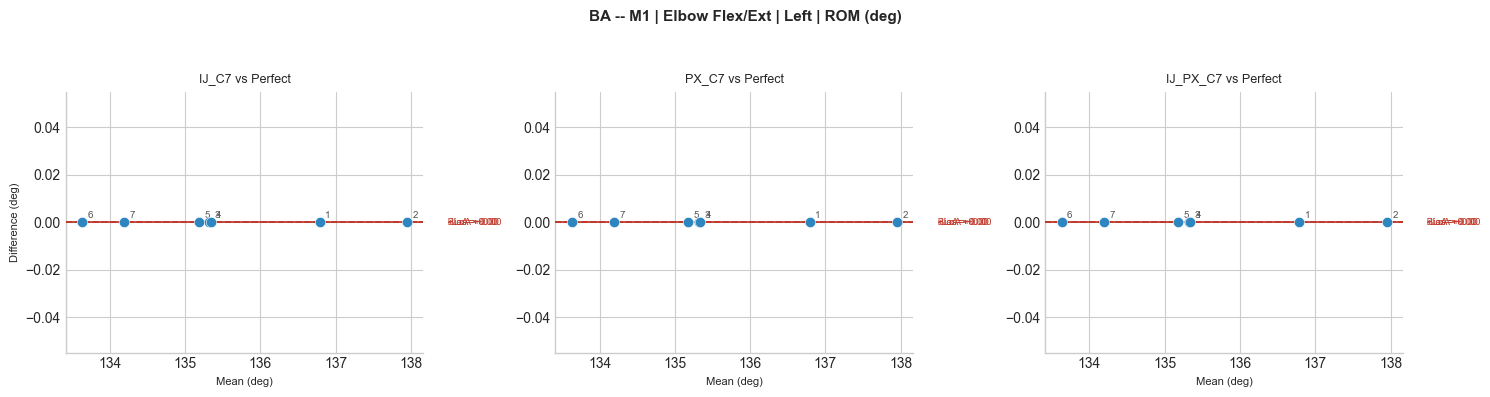

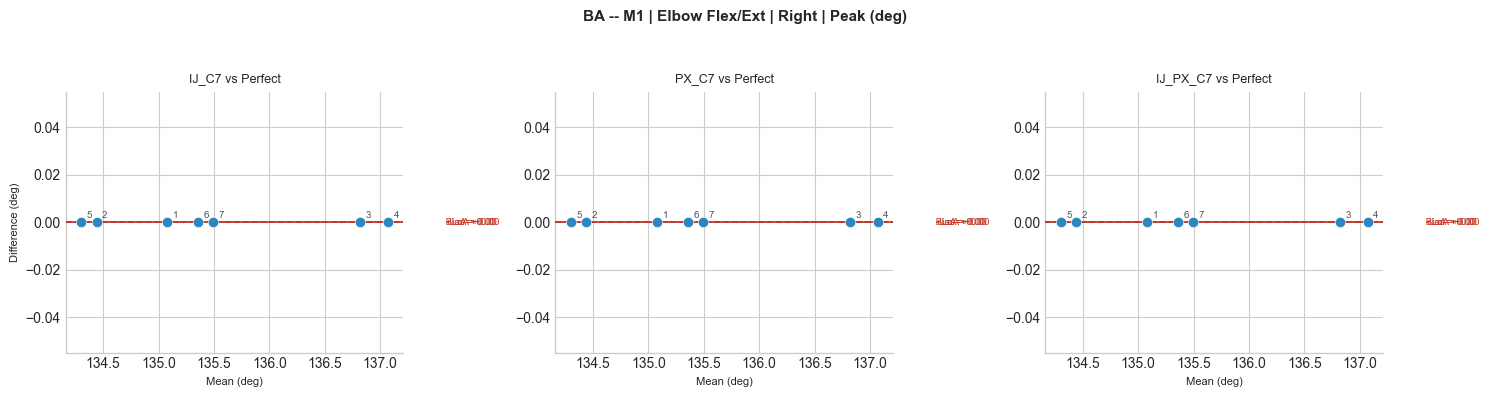

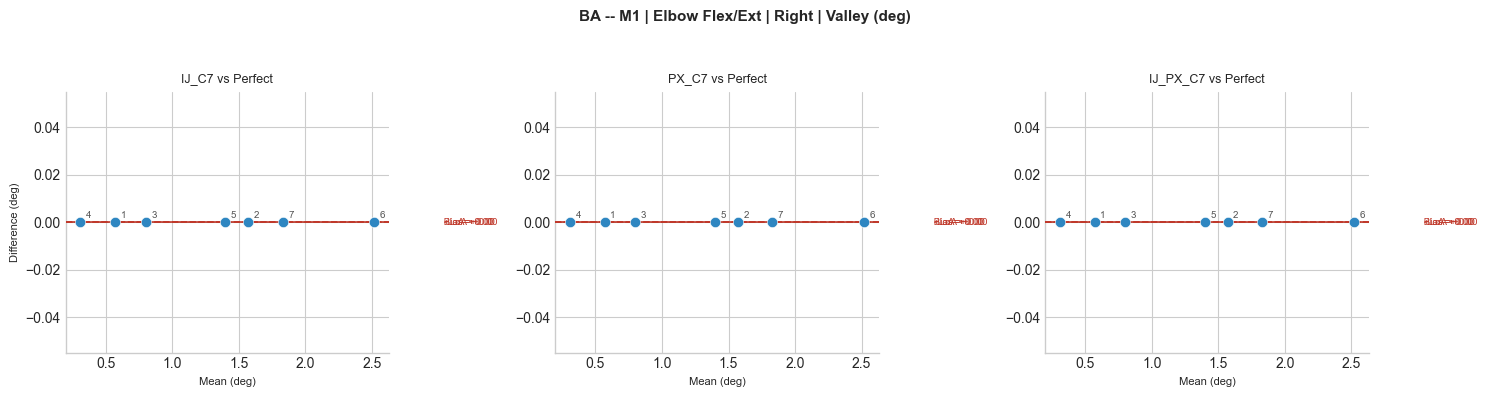

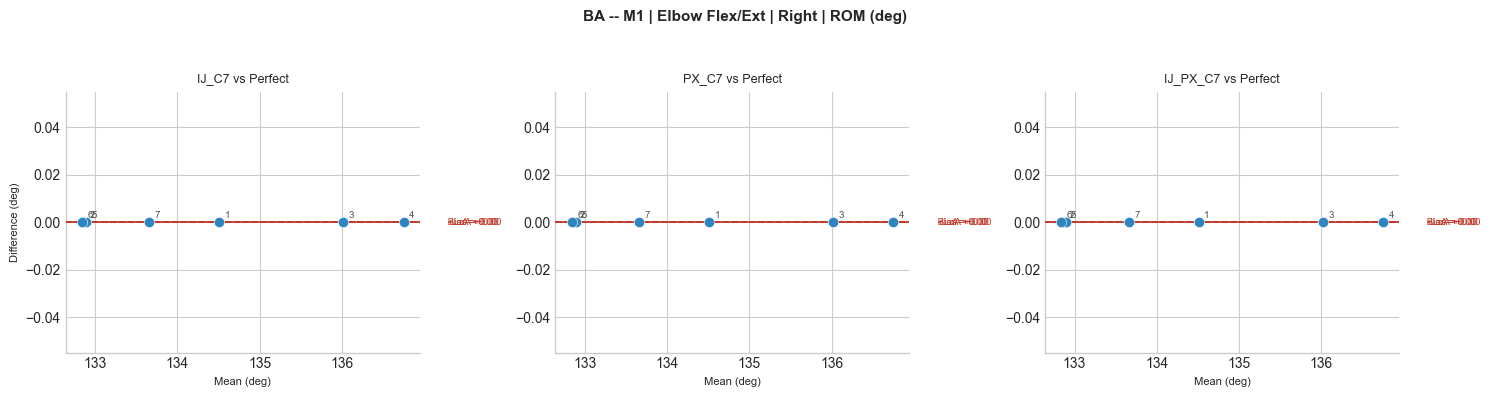

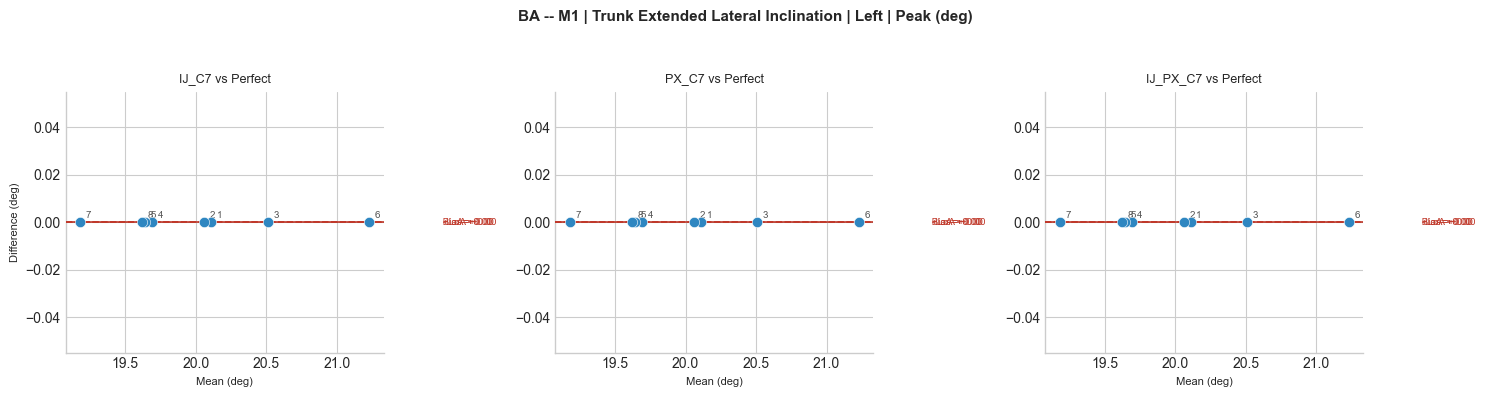

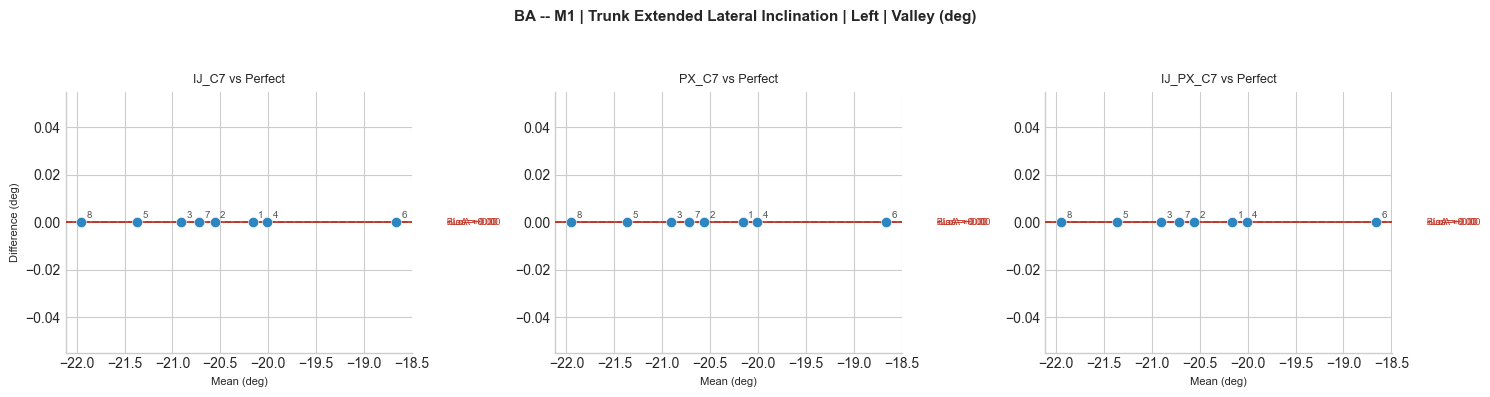

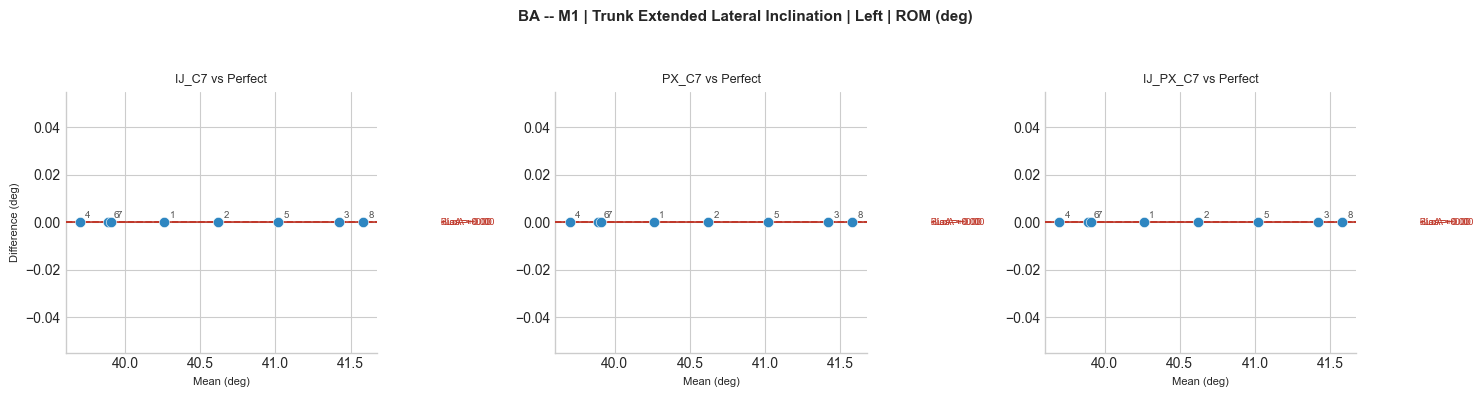

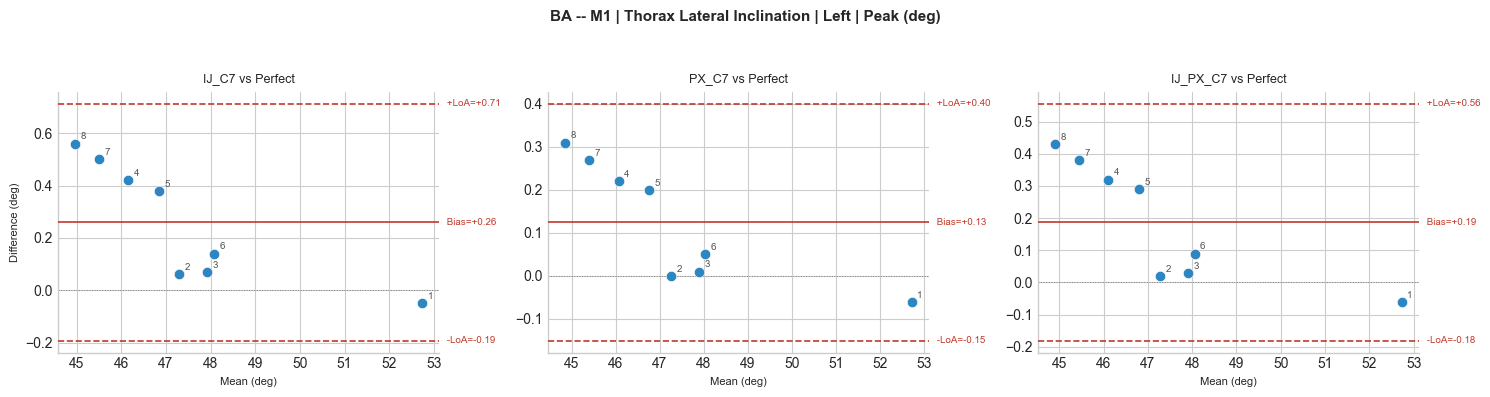

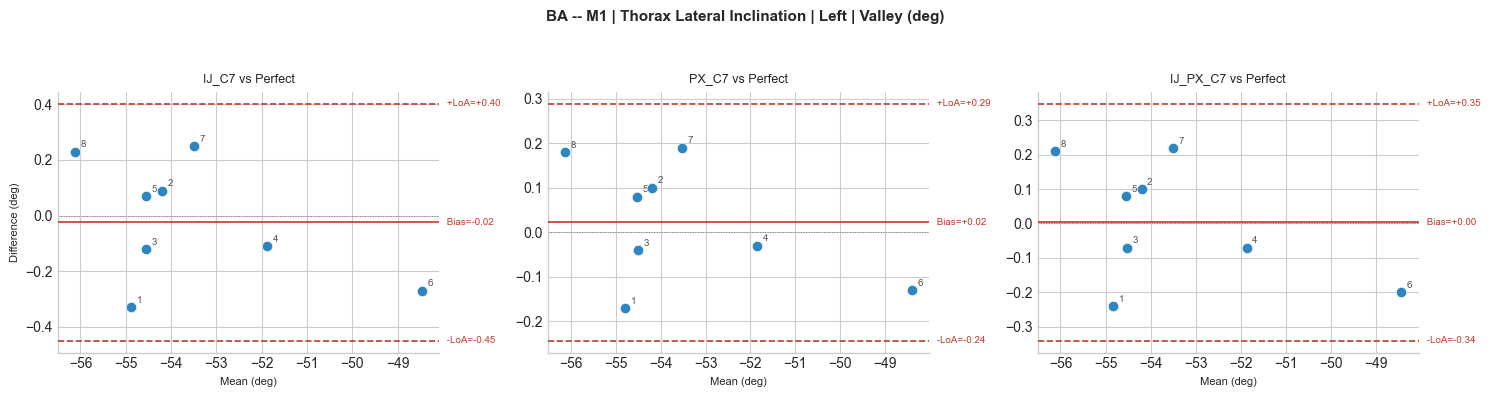

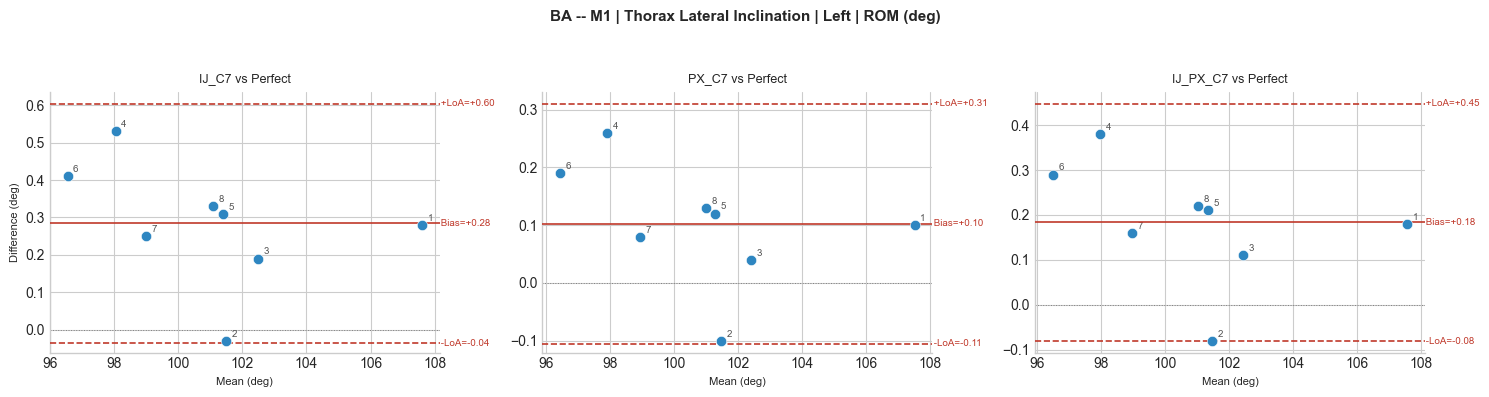

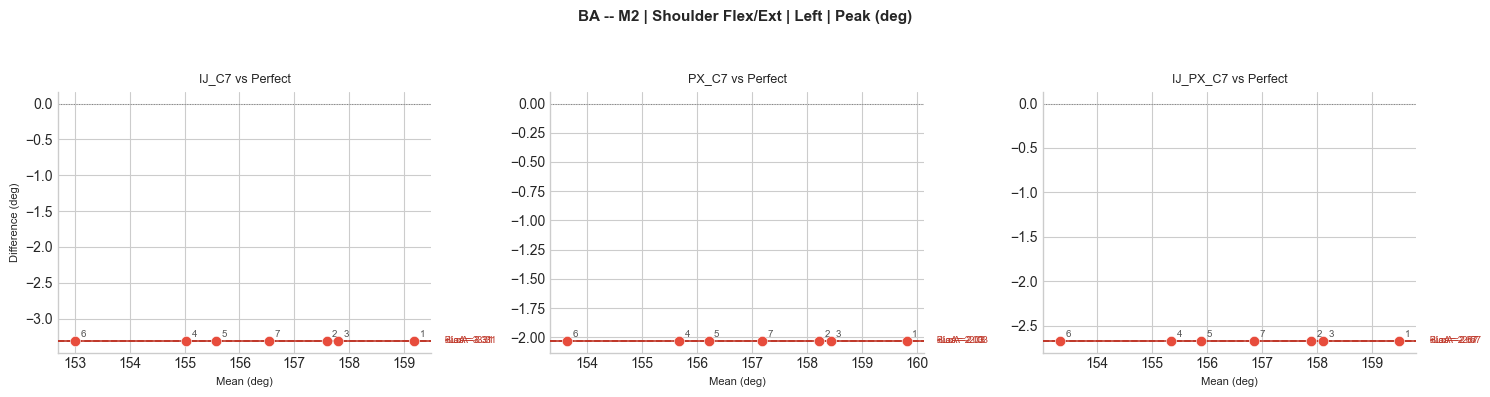

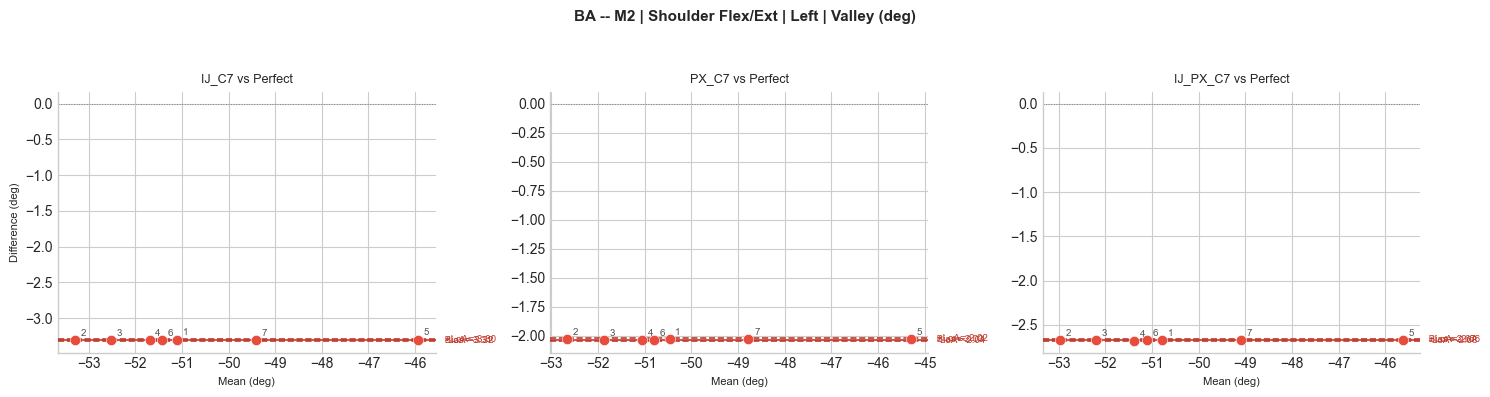

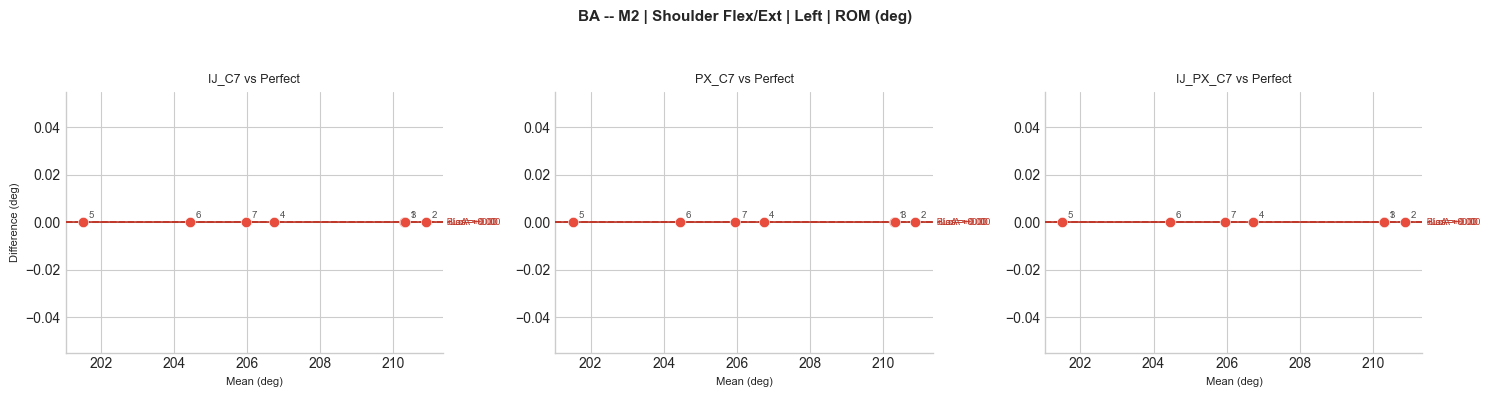

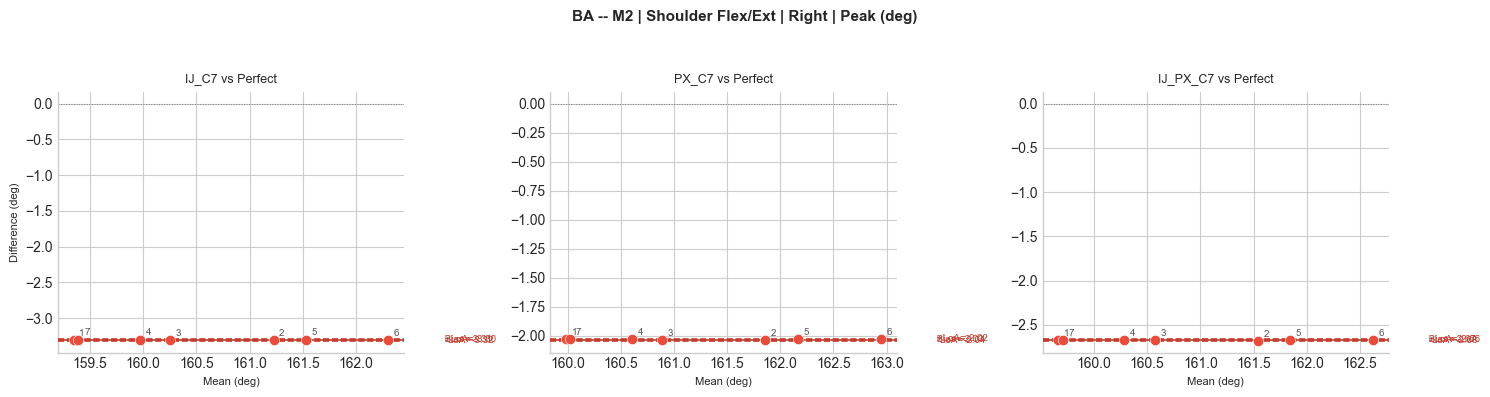

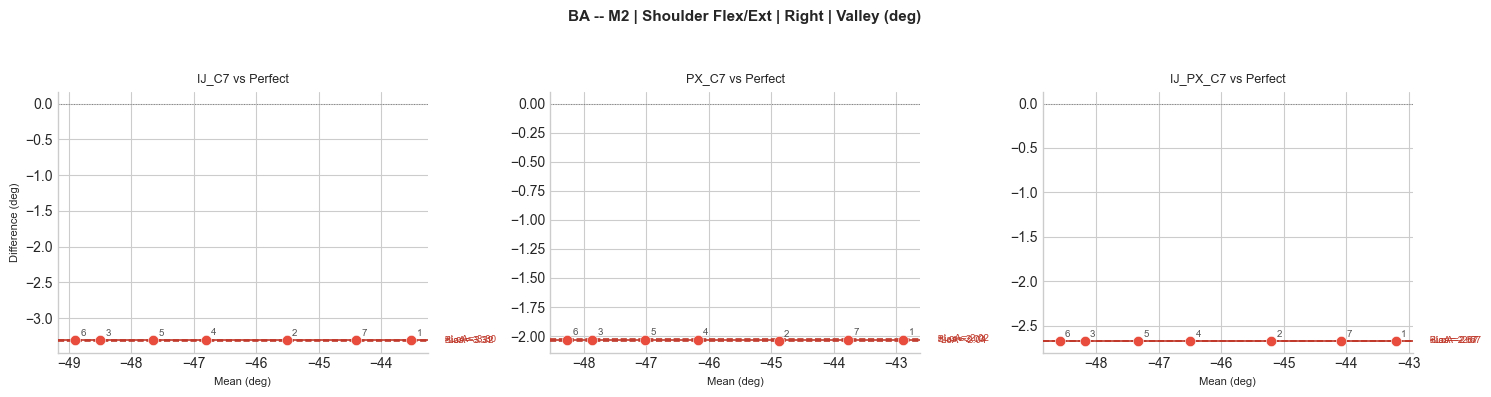

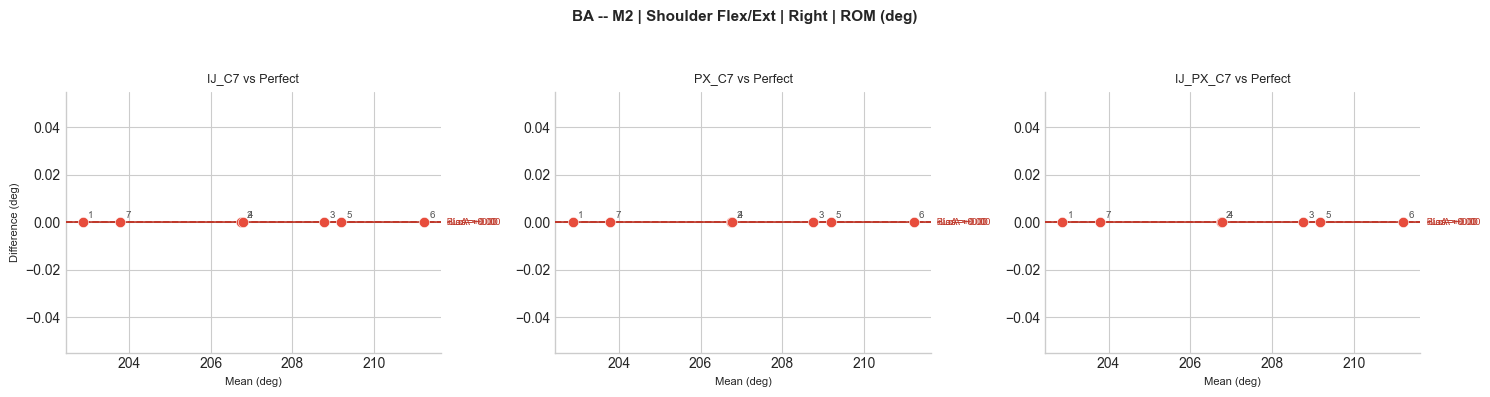

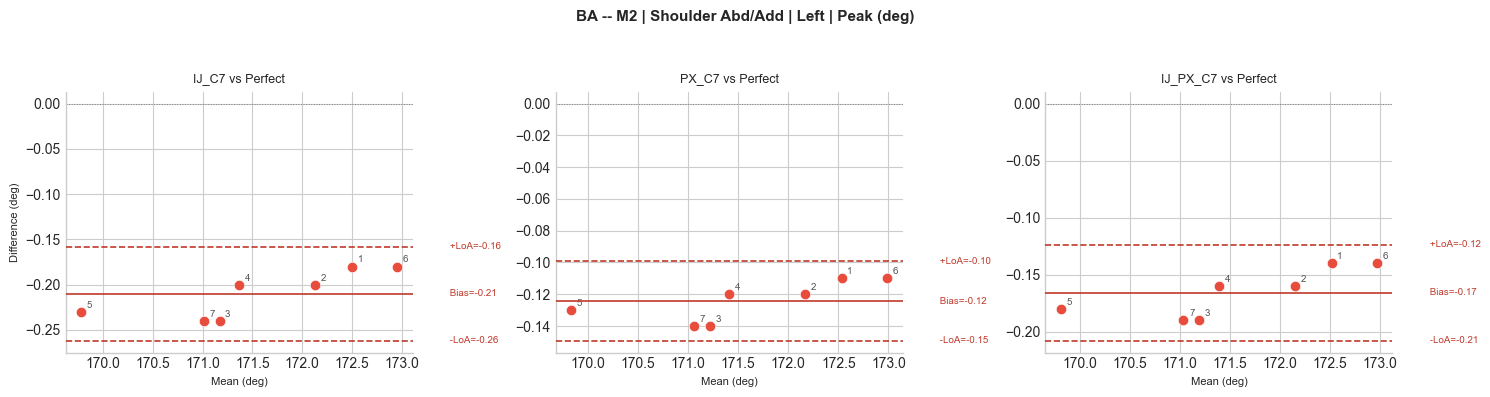

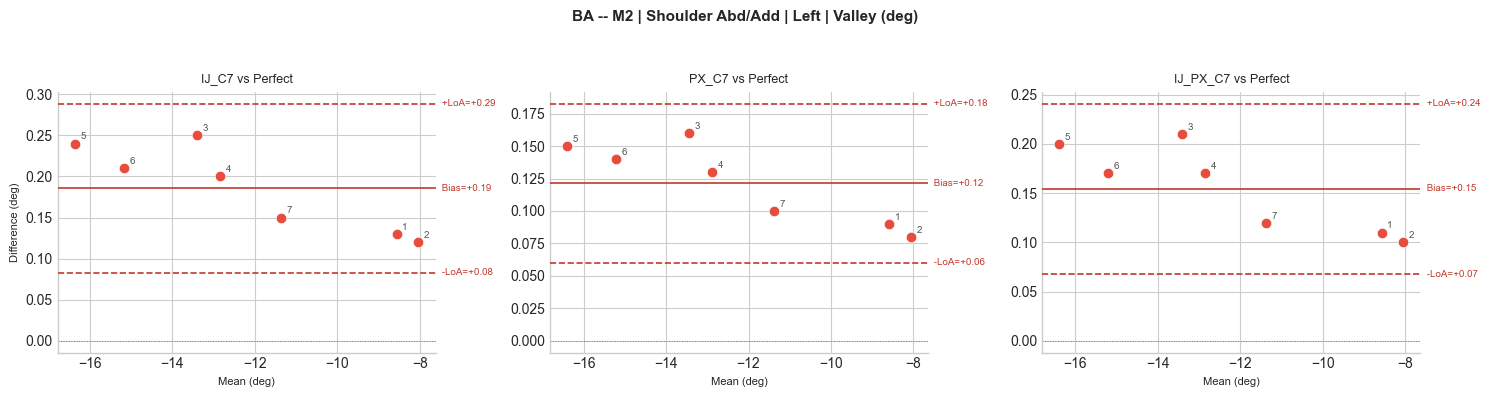

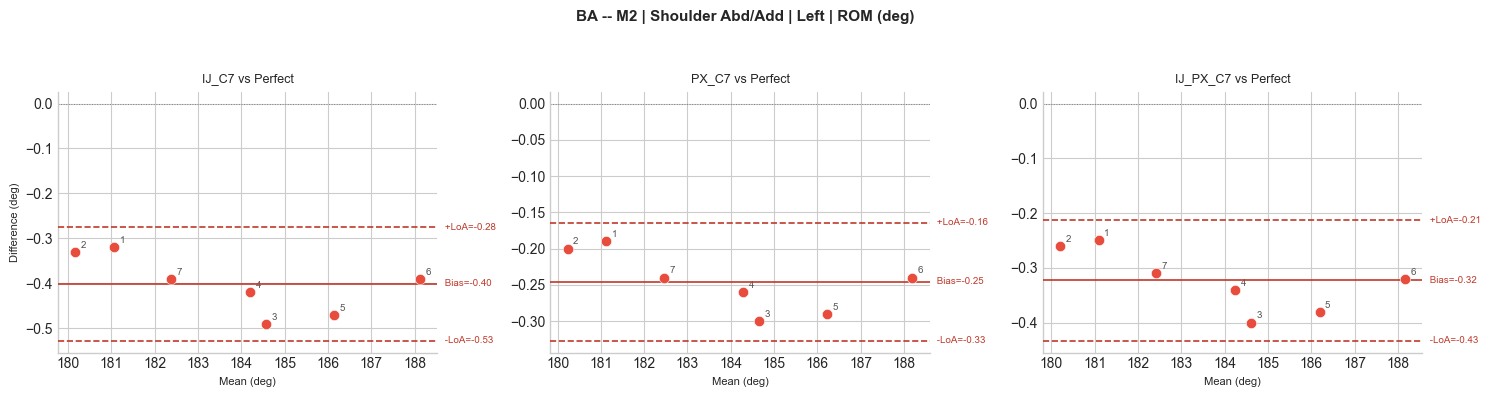

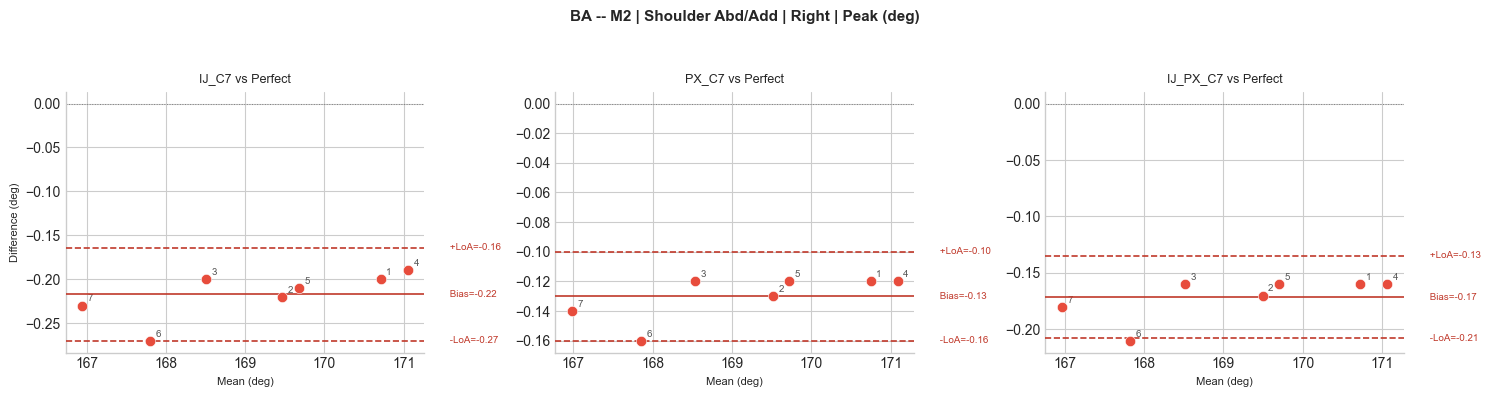

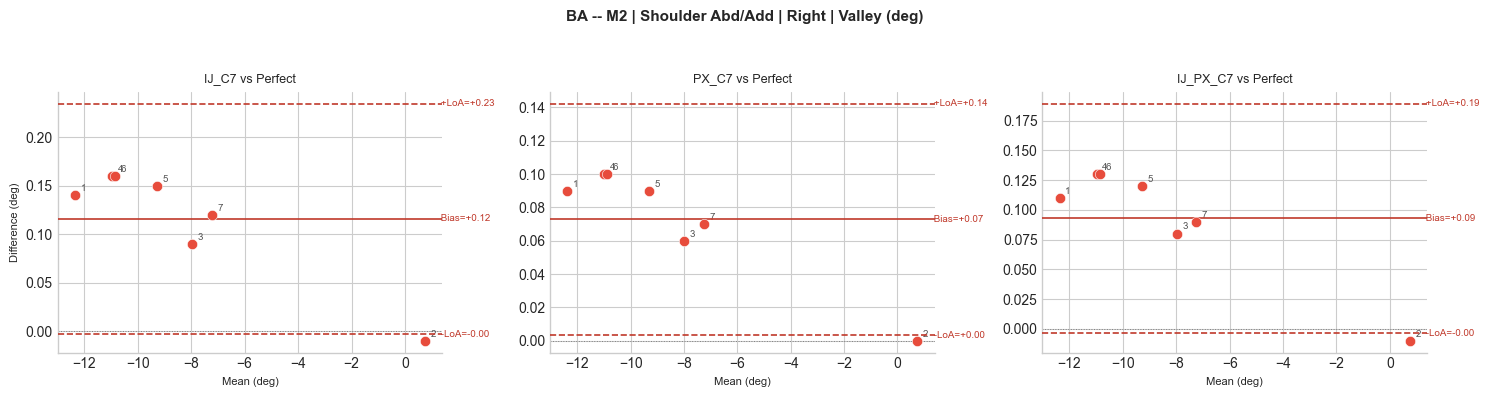

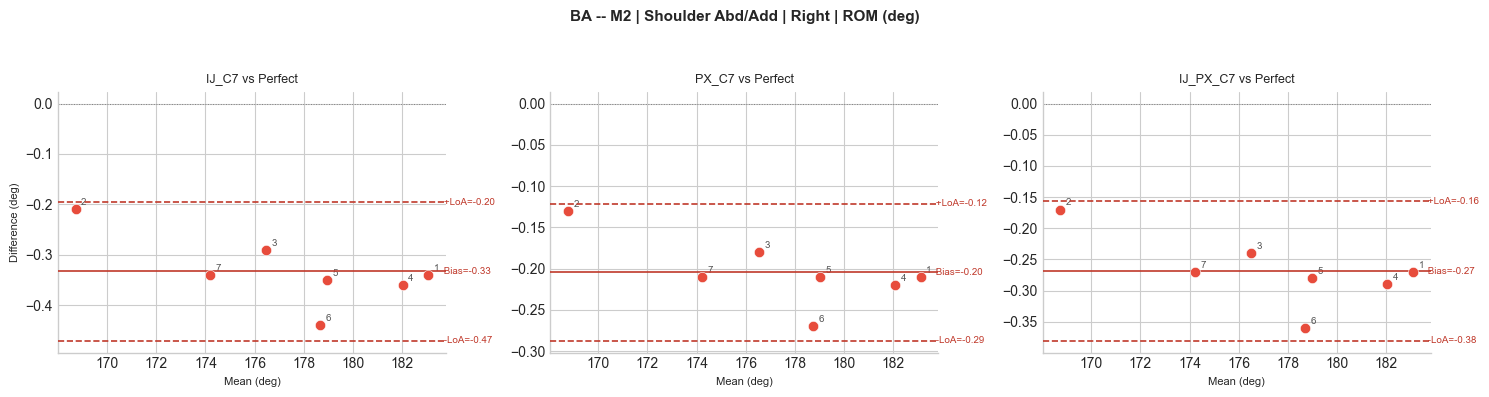

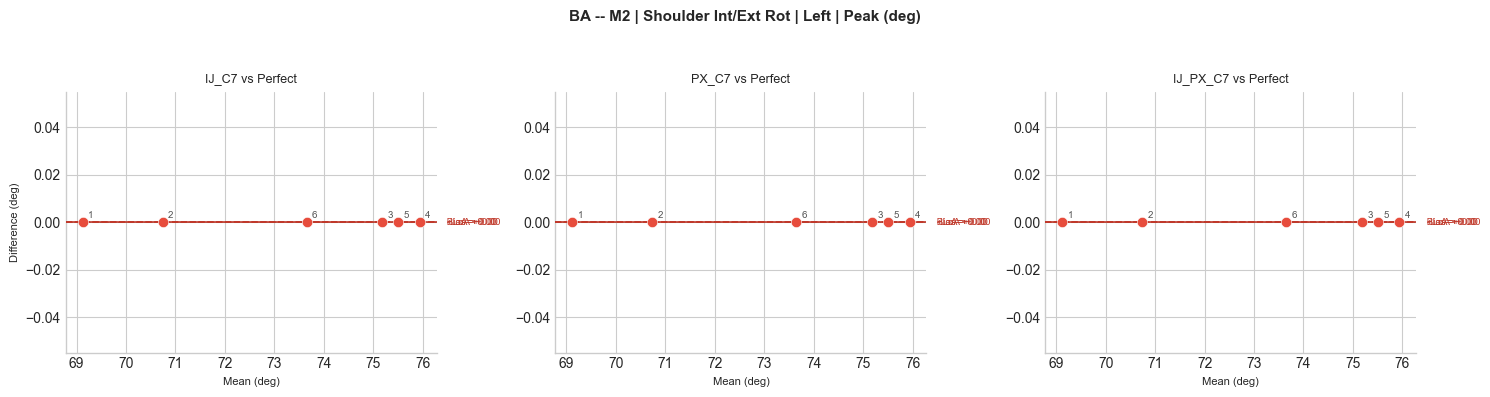

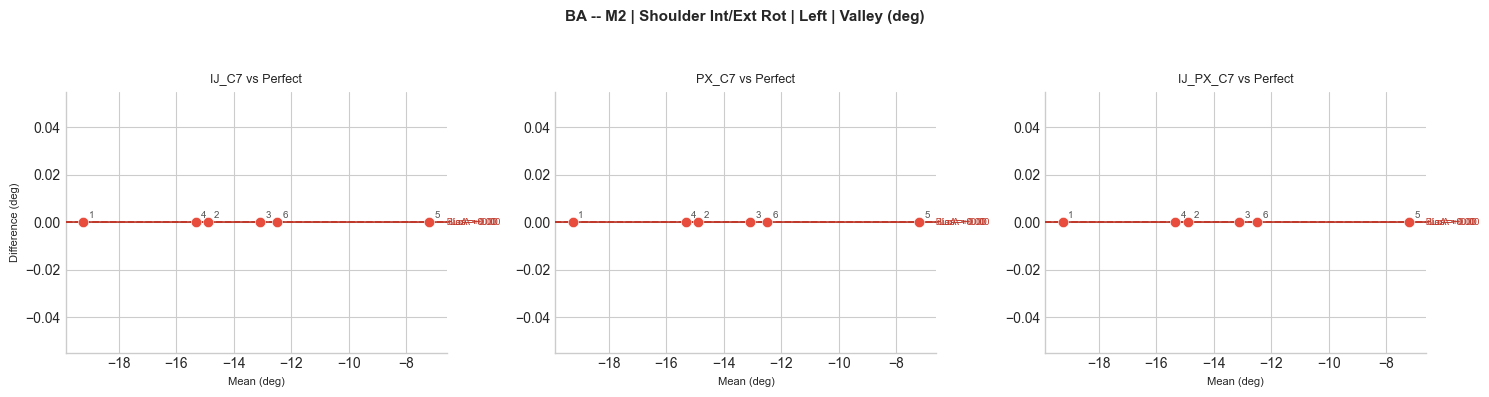

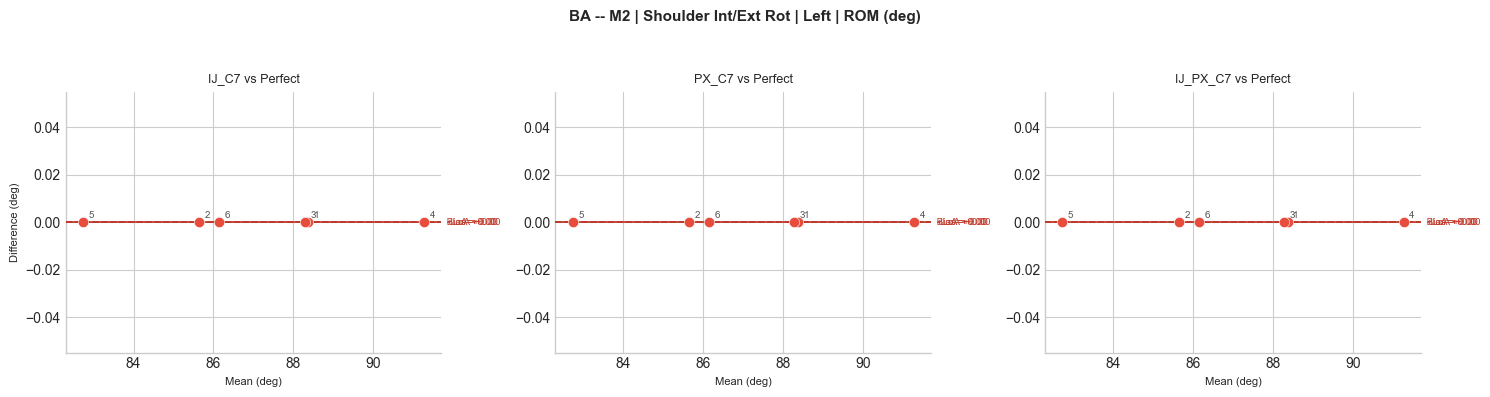

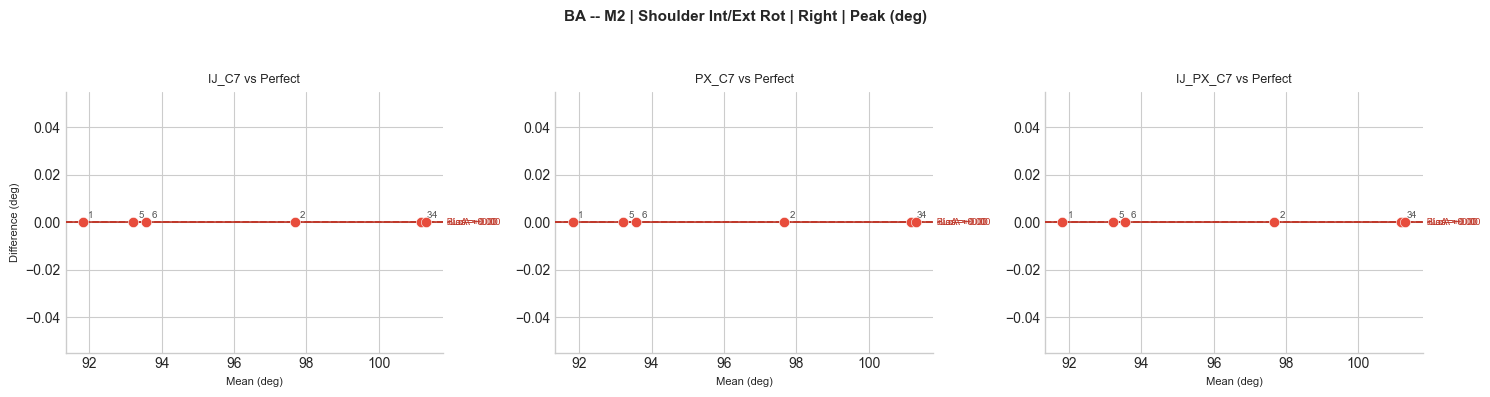

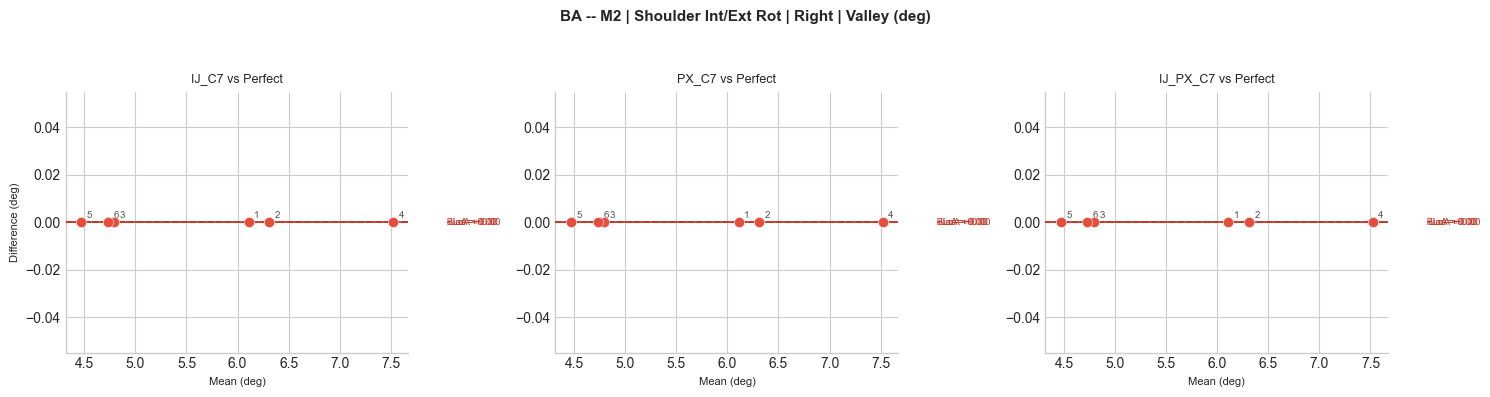

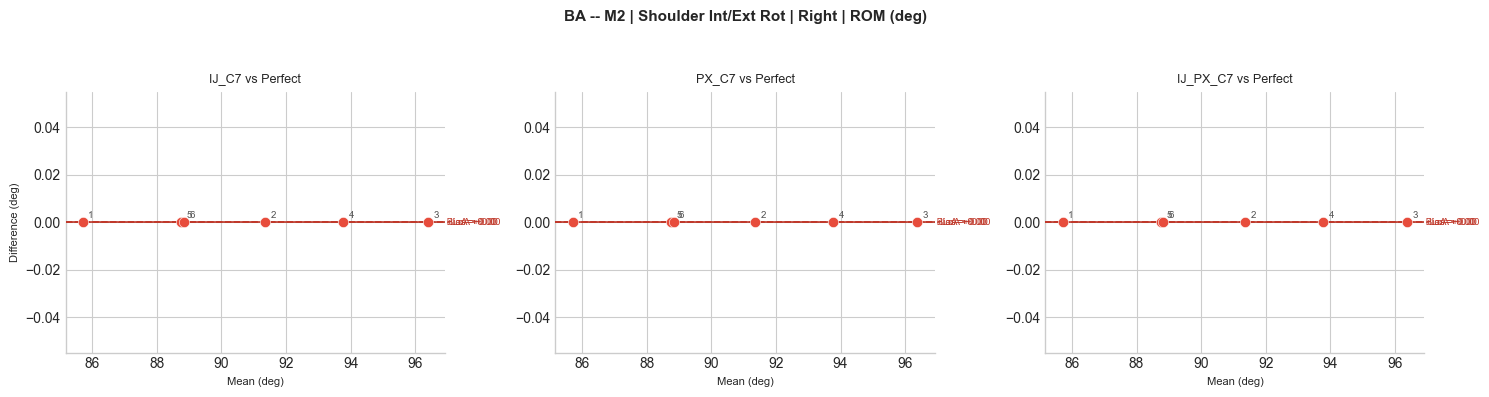

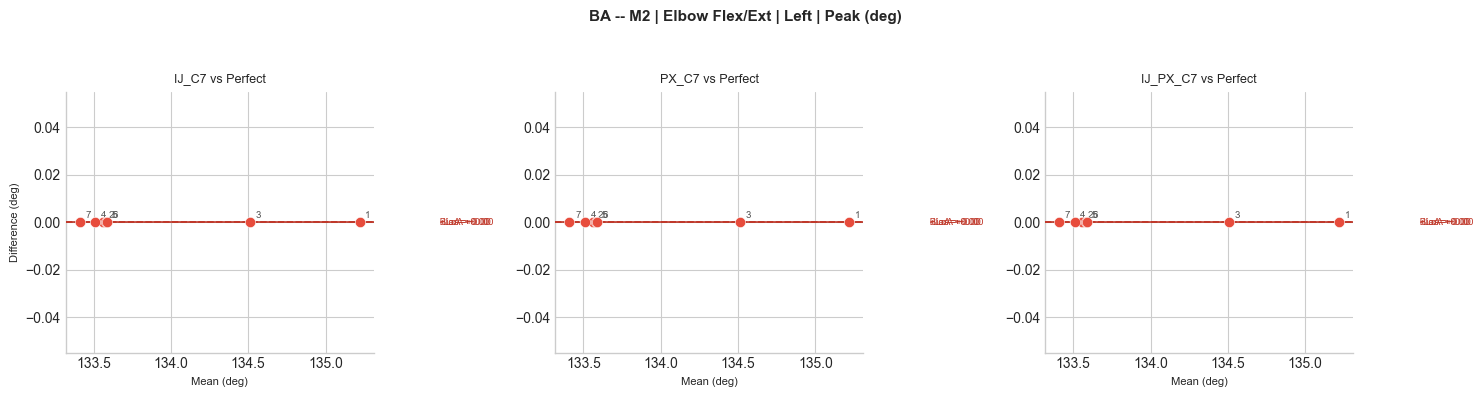

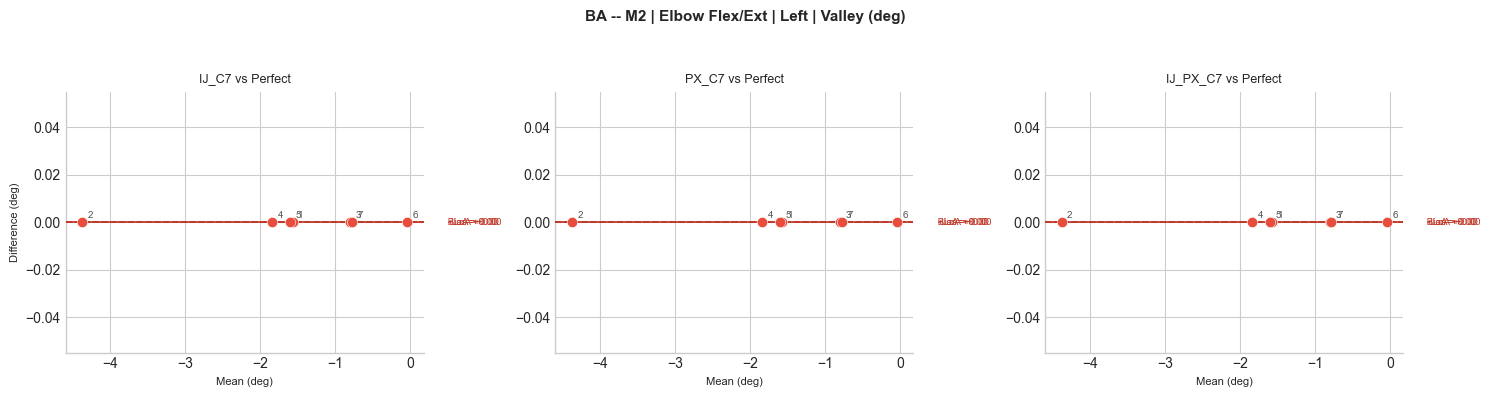

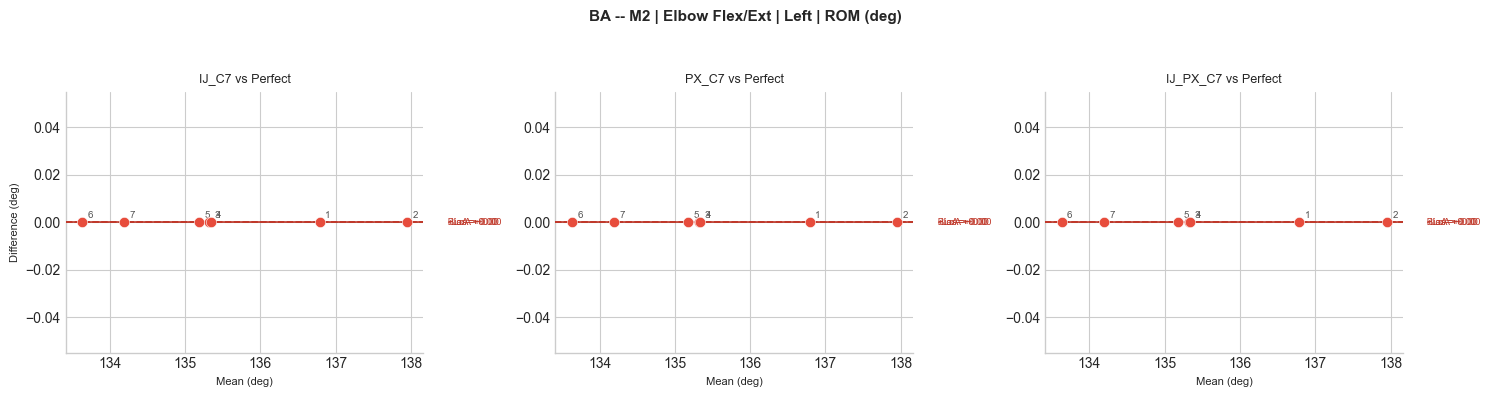

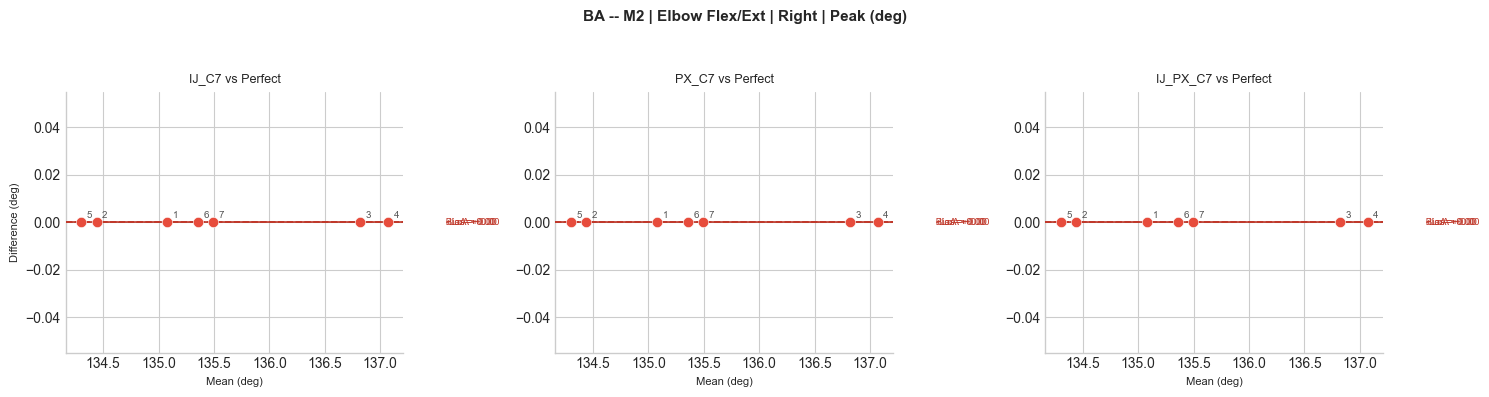

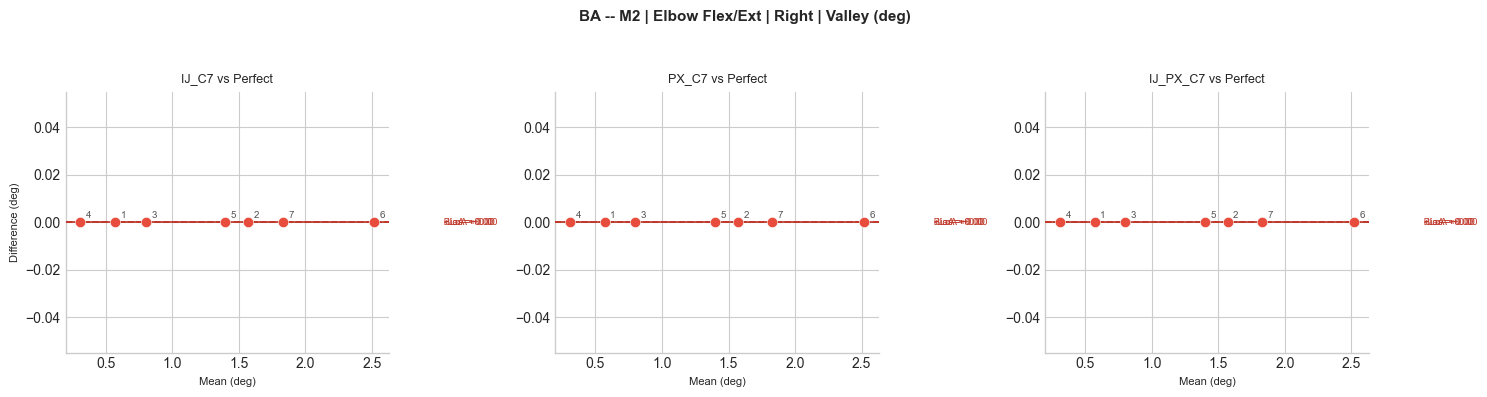

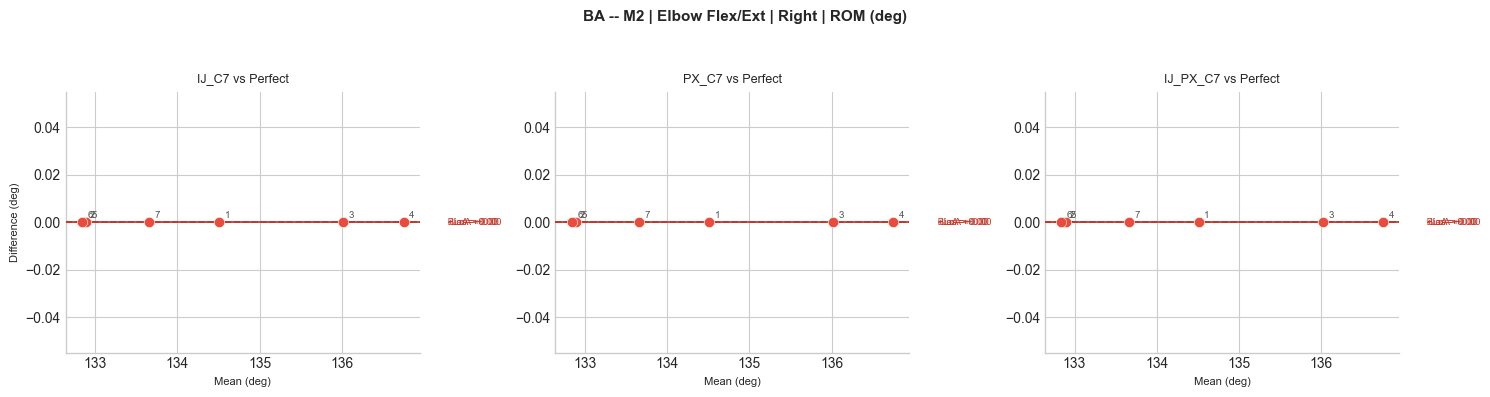

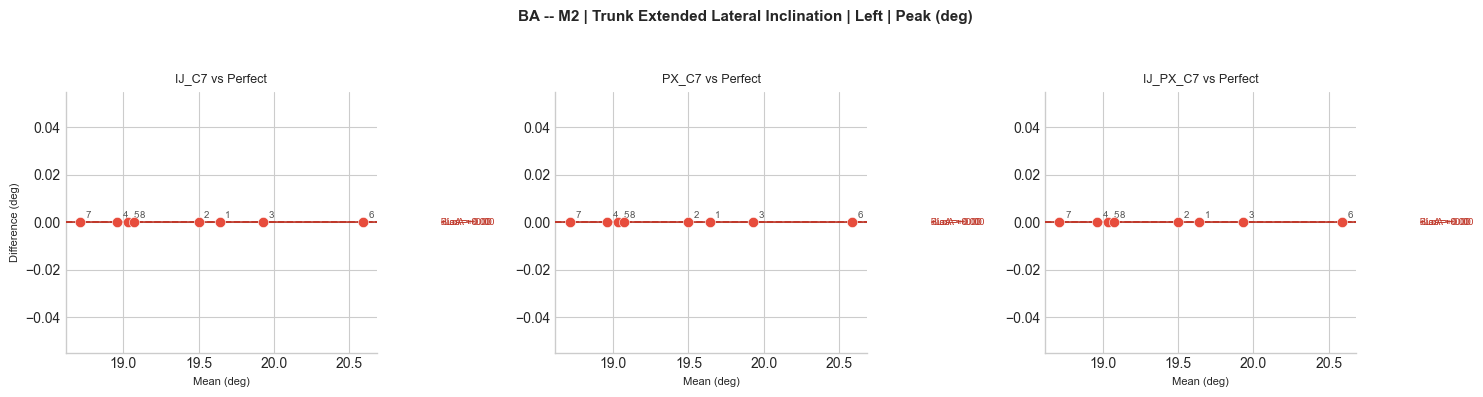

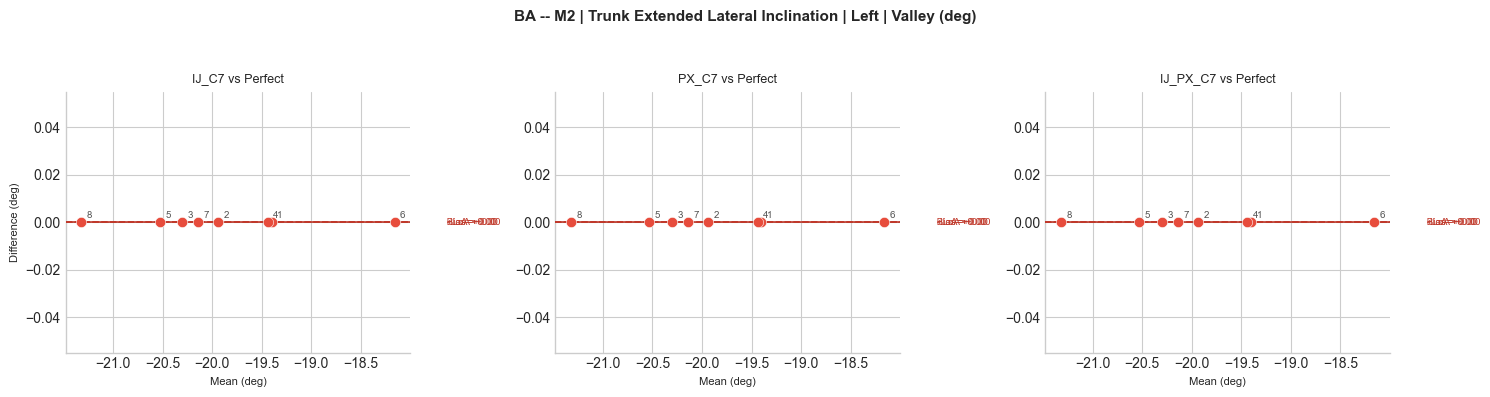

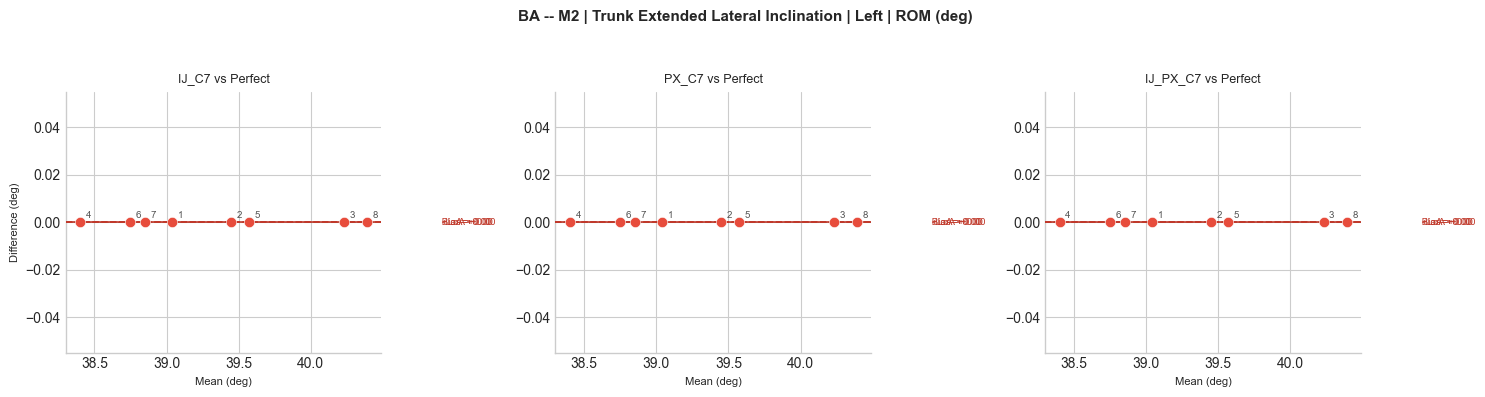

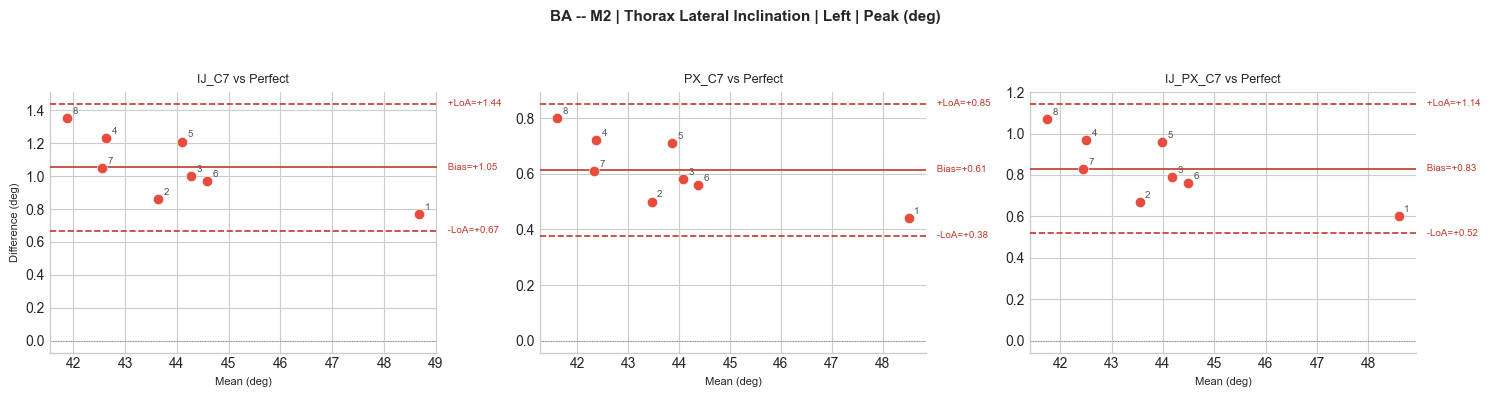

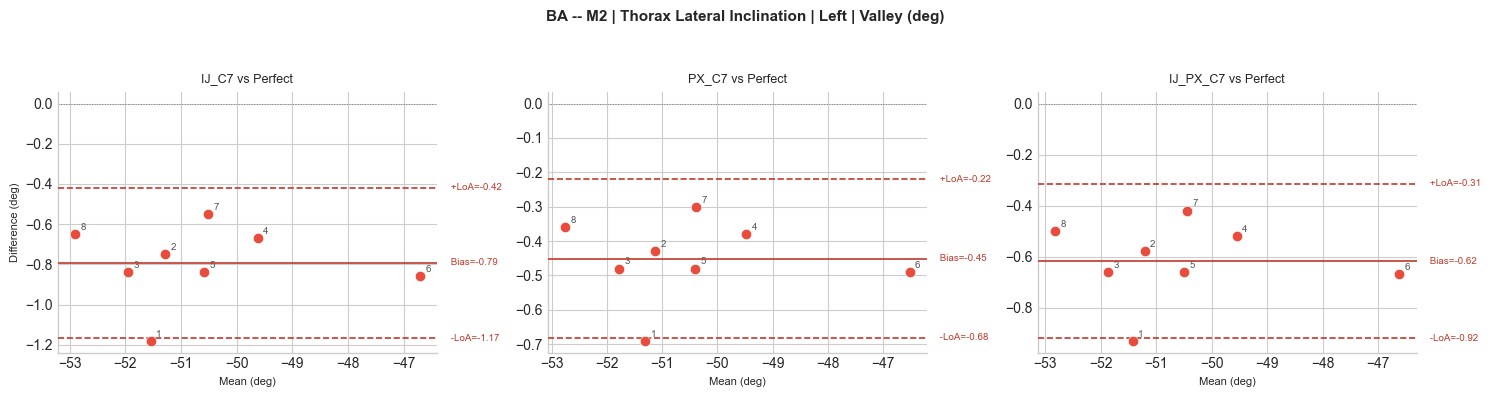

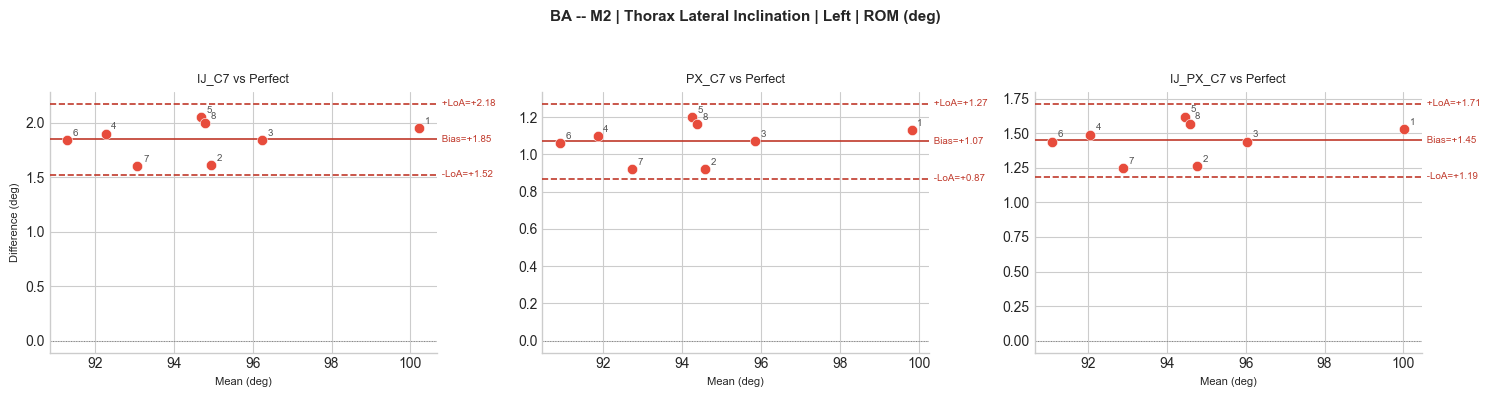

In [13]:
for model in ['M1', 'M2']:
    csv_model = MODEL_CSV[model]
    for movement in MOVEMENT_LIST:
        for side in get_sides(movement):
            for var in ANGLE_VARS:
                y_ref = get_array(df, movement, model, 'Perfect', side, var)
                fig, axes = plt.subplots(1, 3, figsize=(15, 4))
                fig.suptitle(
                    f'BA -- {model} | {movement} | {side} | {VAR_LABELS[var]}',
                    fontsize=11, fontweight='bold',
                )
                for ax, anat_dist in zip(axes, ANAT_CONDITIONS):
                    y_alt = get_array(df, movement, model, anat_dist, side, var)
                    n = min(len(y_ref), len(y_alt))
                    yr, ya = y_ref[:n], y_alt[:n]
                    means  = (yr + ya) / 2
                    diffs  = ya - yr
                    bias_v = float(np.mean(diffs))
                    sd_v   = float(np.std(diffs, ddof=1))
                    loa_up = bias_v + 1.96 * sd_v
                    loa_lo = bias_v - 1.96 * sd_v

                    ax.scatter(means, diffs, color=MODEL_COLORS[model],
                               s=55, zorder=4, edgecolors='white', linewidths=0.4)
                    reps = (df[
                        (df['Movement'] == movement) &
                        (df['Model']    == csv_model) &
                        (df['Anatomic_Distances'] == anat_dist)
                    ].sort_values('Rep')['Rep'].tolist())[:n]
                    for mx, dy, rep in zip(means, diffs, reps):
                        ax.annotate(str(rep), (mx, dy),
                                    textcoords='offset points', xytext=(4, 3),
                                    fontsize=7, color='#555555')
                    x_right = float(means.max()) + 0.5 if len(means) else 1.0
                    for val, ls, lbl in [
                        (bias_v, '-',  f'Bias={bias_v:+.2f}'),
                        (loa_up, '--', f'+LoA={loa_up:+.2f}'),
                        (loa_lo, '--', f'-LoA={loa_lo:+.2f}'),
                    ]:
                        ax.axhline(val, linestyle=ls, color='#C0392B',
                                   linewidth=1.2, zorder=3)
                        ax.text(x_right, val, f' {lbl}', va='center', ha='left',
                                fontsize=7, color='#C0392B', clip_on=False)
                    ax.axhline(0, color='gray', linewidth=0.7, linestyle=':', zorder=2)
                    ax.set_title(f'{anat_dist} vs Perfect', fontsize=9)
                    ax.set_xlabel('Mean (deg)', fontsize=8)
                    if ax is axes[0]:
                        ax.set_ylabel('Difference (deg)', fontsize=8)
                    ax.spines['top'].set_visible(False)
                    ax.spines['right'].set_visible(False)
                plt.tight_layout(rect=[0, 0, 1, 0.93])
                plt.show()
                plt.close(fig)


### 6.3 — ROM RMSD Grouped Bar Chart (Comparison A)

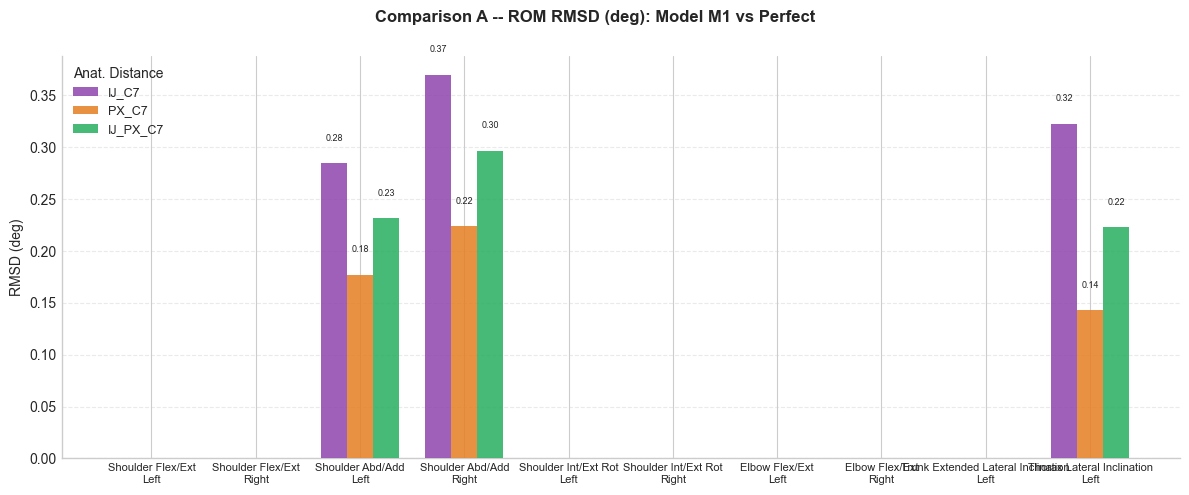

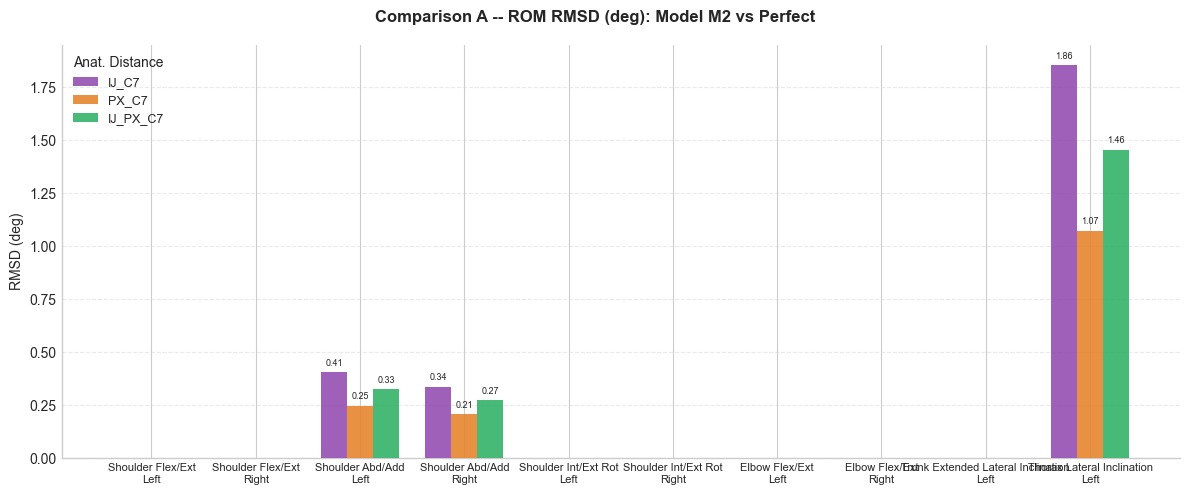

In [14]:
for model in ['M1', 'M2']:
    sub = df_A[(df_A['model'] == model) & (df_A['angle_var'] == 'ROM_deg')]
    groups = [(mv, sd) for mv in MOVEMENT_LIST for sd in get_sides(mv)]
    n_g = len(groups)
    x = np.arange(n_g)
    bar_w = 0.25
    offsets = np.linspace(-bar_w, bar_w, 3)

    fig, ax = plt.subplots(figsize=(max(10, n_g * 1.2), 5))
    fig.suptitle(
        f'Comparison A -- ROM RMSD (deg): Model {model} vs Perfect',
        fontsize=12, fontweight='bold',
    )
    for i, anat_dist in enumerate(ANAT_CONDITIONS):
        vals = []
        for mv, sd in groups:
            row = sub[(sub['movement'] == mv) & (sub['side'] == sd) &
                      (sub['anat_dist'] == anat_dist)]
            vals.append(float(row['rmsd_deg'].iloc[0]) if not row.empty else 0.0)
        bars = ax.bar(x + offsets[i], vals, bar_w,
                      label=anat_dist, color=list(ANAT_COLORS.values())[i],
                      alpha=0.85, zorder=3)
        for bar, val in zip(bars, vals):
            if val > 0.01:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=6.5)
    labels = [f'{mv}\n{sd}' for mv, sd in groups]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('RMSD (deg)', fontsize=10)
    ax.legend(title='Anat. Distance', fontsize=9, framealpha=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()


### 6.4 — ICC Summary Bar Chart (Comparison B.1)

One figure per angle_var (3 total), two subplots per figure (Left / Right sides).

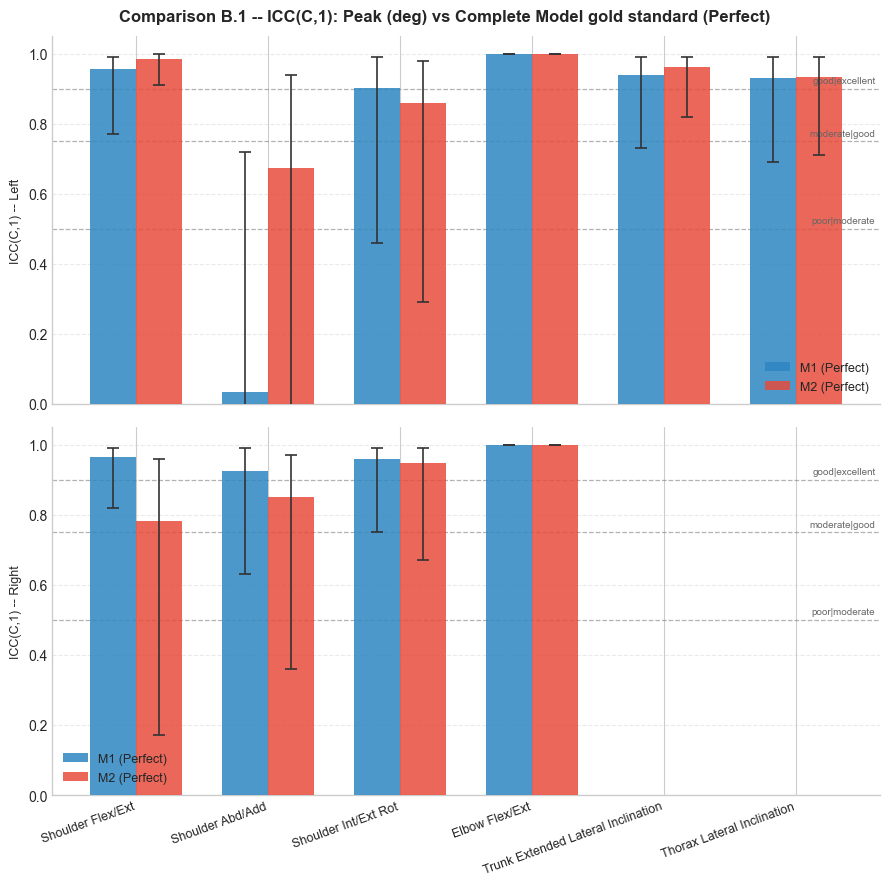

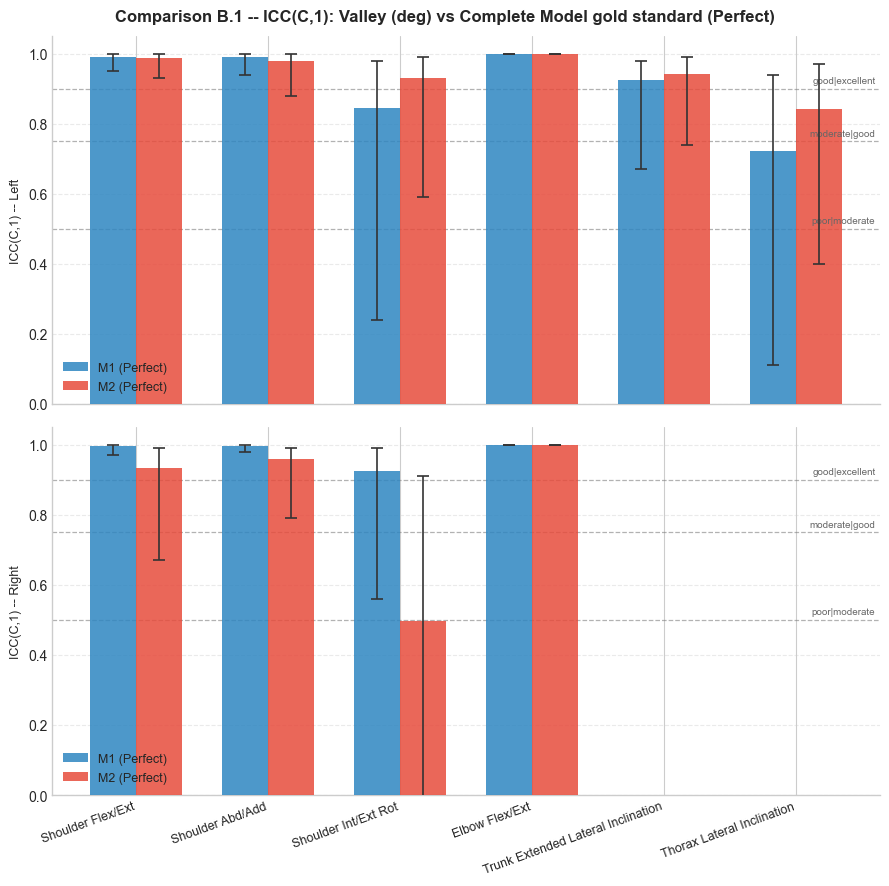

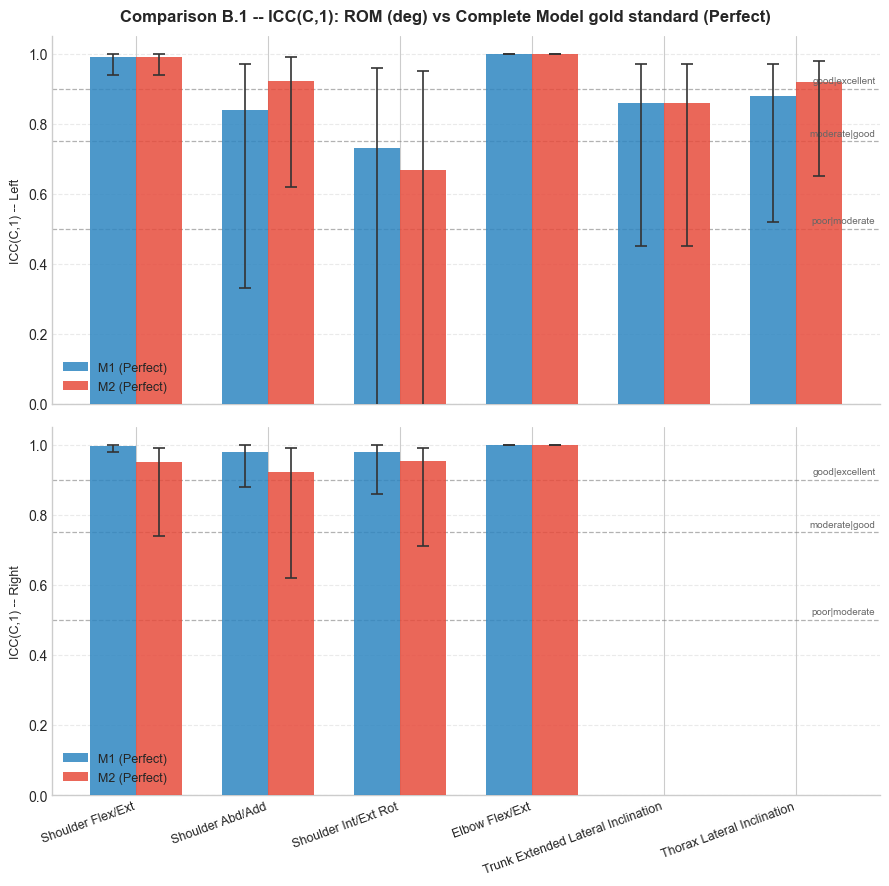

In [15]:
for var in ANGLE_VARS:
    sub_var = df_B1[df_B1['angle_var'] == var]
    fig, axes = plt.subplots(2, 1,
                             figsize=(max(9, len(MOVEMENT_LIST) * 1.3), 9),
                             sharex=True)
    fig.suptitle(
        f'Comparison B.1 -- ICC(C,1): {VAR_LABELS[var]} vs Complete Model gold standard (Perfect)',
        fontsize=12, fontweight='bold',
    )
    x = np.arange(len(MOVEMENT_LIST))
    width = 0.35
    for ax, side in zip(axes, ['Left', 'Right']):
        sub_side = sub_var[sub_var['side'] == side]
        for i, model in enumerate(['M1', 'M2']):
            m_sub = sub_side[sub_side['model'] == model]
            icc_vals, err_lo, err_hi = [], [], []
            for mv in MOVEMENT_LIST:
                row = m_sub[m_sub['movement'] == mv]
                if row.empty or np.isnan(float(row['icc'].iloc[0])):
                    icc_vals.append(np.nan)
                    err_lo.append(0)
                    err_hi.append(0)
                else:
                    v = float(row['icc'].iloc[0])
                    icc_vals.append(v)
                    err_lo.append(max(0.0, v - float(row['icc_ci95_lower'].iloc[0])))
                    err_hi.append(max(0.0, float(row['icc_ci95_upper'].iloc[0]) - v))
            ax.bar(x + (i - 0.5) * width, icc_vals, width,
                   label=f'{model} (Perfect)', color=MODEL_COLORS[model],
                   alpha=0.85, zorder=3)
            ax.errorbar(x + (i - 0.5) * width, icc_vals,
                        yerr=[err_lo, err_hi],
                        fmt='none', color='#333333',
                        capsize=4, capthick=1.2, elinewidth=1.2, zorder=4)
        for thresh, lbl in [
            (0.50, 'poor|moderate'),
            (0.75, 'moderate|good'),
            (0.90, 'good|excellent'),
        ]:
            ax.axhline(thresh, color='gray', linewidth=0.9,
                       linestyle='--', alpha=0.6)
            ax.text(len(MOVEMENT_LIST) - 0.4, thresh + 0.01, lbl,
                    fontsize=7, color='#666666', va='bottom', ha='right')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(f'ICC(C,1) -- {side}', fontsize=9)
        ax.legend(fontsize=9, framealpha=0.8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
        ax.set_axisbelow(True)
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(MOVEMENT_LIST, rotation=20, ha='right', fontsize=9)
    plt.tight_layout()
    plt.show()


### 6.5 — ICC Summary Bar Chart (Comparison B.2)

Same layout as section 6.4, using `IJ_PX_C7` distances for reconstructed models instead of `Perfect`.

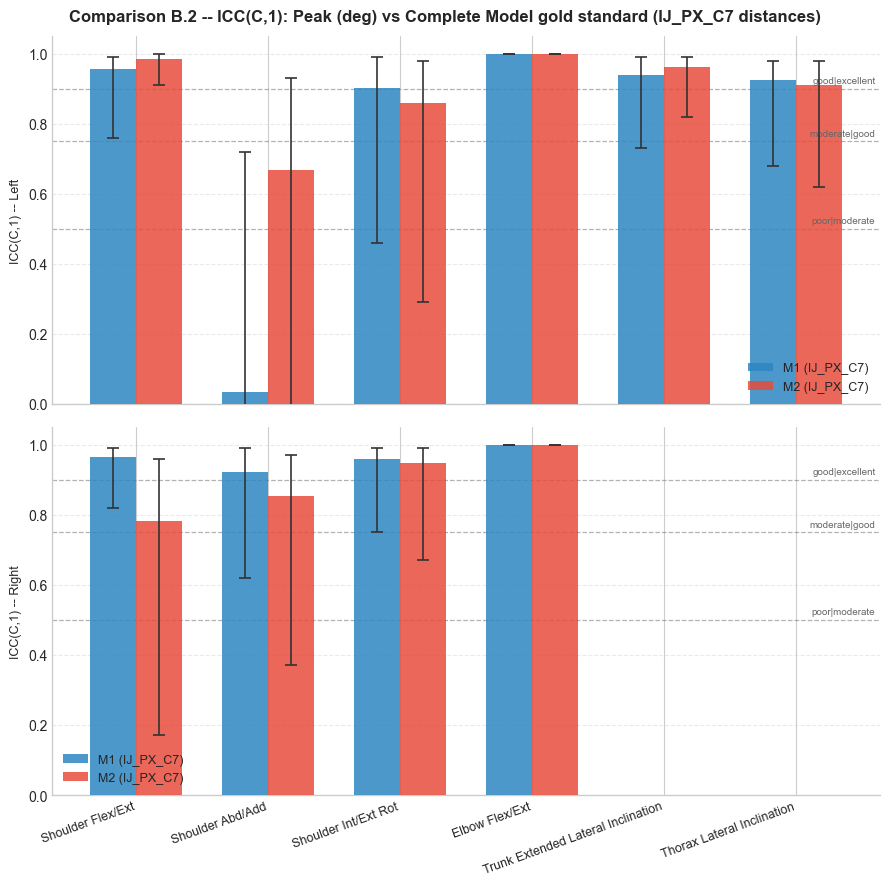

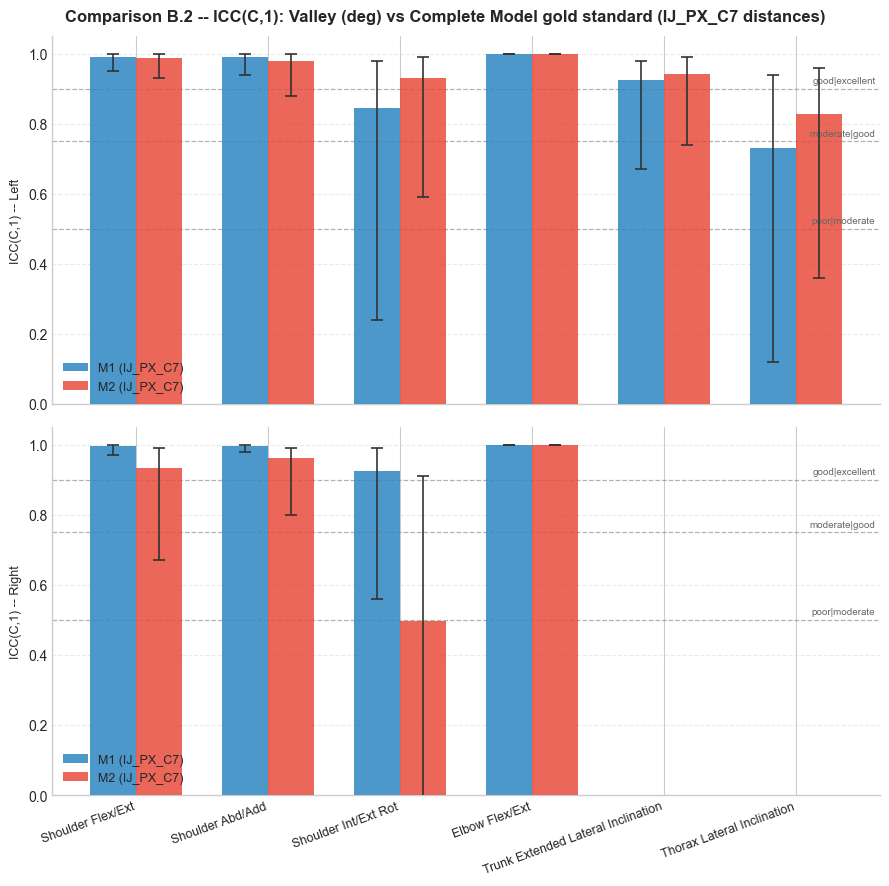

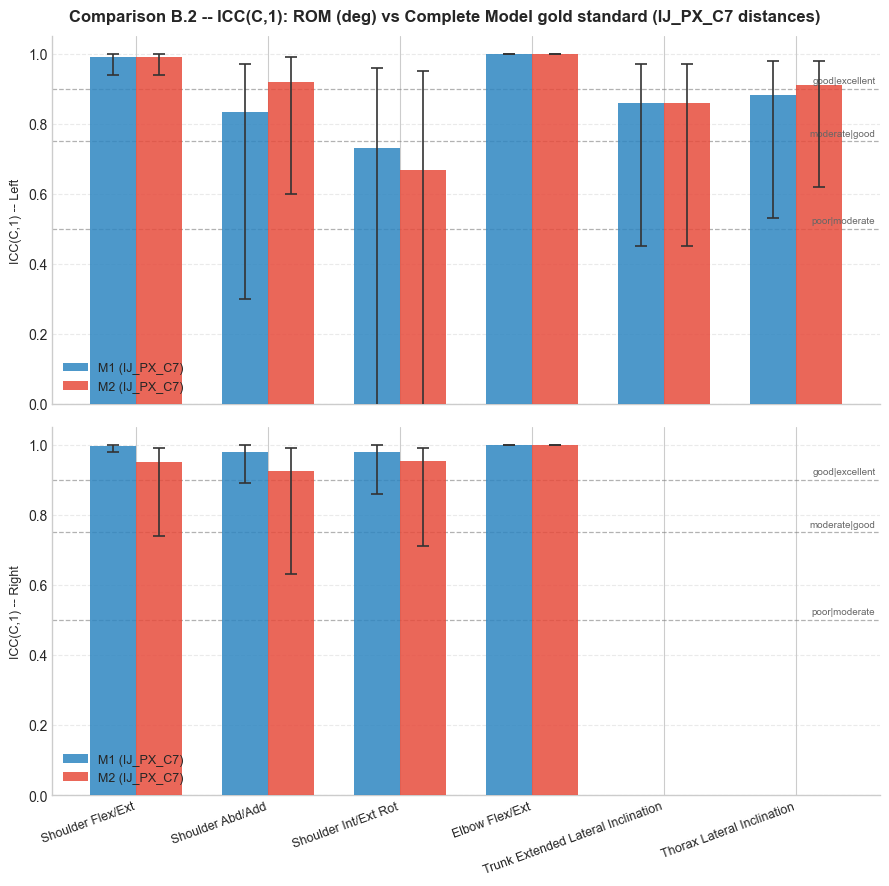

In [16]:
for var in ANGLE_VARS:
    sub_var = df_B2[df_B2['angle_var'] == var]
    fig, axes = plt.subplots(2, 1,
                             figsize=(max(9, len(MOVEMENT_LIST) * 1.3), 9),
                             sharex=True)
    fig.suptitle(
        f'Comparison B.2 -- ICC(C,1): {VAR_LABELS[var]} vs Complete Model gold standard (IJ_PX_C7 distances)',
        fontsize=12, fontweight='bold',
    )
    x = np.arange(len(MOVEMENT_LIST))
    width = 0.35
    for ax, side in zip(axes, ['Left', 'Right']):
        sub_side = sub_var[sub_var['side'] == side]
        for i, model in enumerate(['M1', 'M2']):
            m_sub = sub_side[sub_side['model'] == model]
            icc_vals, err_lo, err_hi = [], [], []
            for mv in MOVEMENT_LIST:
                row = m_sub[m_sub['movement'] == mv]
                if row.empty or np.isnan(float(row['icc'].iloc[0])):
                    icc_vals.append(np.nan)
                    err_lo.append(0)
                    err_hi.append(0)
                else:
                    v = float(row['icc'].iloc[0])
                    icc_vals.append(v)
                    err_lo.append(max(0.0, v - float(row['icc_ci95_lower'].iloc[0])))
                    err_hi.append(max(0.0, float(row['icc_ci95_upper'].iloc[0]) - v))
            ax.bar(x + (i - 0.5) * width, icc_vals, width,
                   label=f'{model} (IJ_PX_C7)', color=MODEL_COLORS[model],
                   alpha=0.85, zorder=3)
            ax.errorbar(x + (i - 0.5) * width, icc_vals,
                        yerr=[err_lo, err_hi],
                        fmt='none', color='#333333',
                        capsize=4, capthick=1.2, elinewidth=1.2, zorder=4)
        for thresh, lbl in [
            (0.50, 'poor|moderate'),
            (0.75, 'moderate|good'),
            (0.90, 'good|excellent'),
        ]:
            ax.axhline(thresh, color='gray', linewidth=0.9,
                       linestyle='--', alpha=0.6)
            ax.text(len(MOVEMENT_LIST) - 0.4, thresh + 0.01, lbl,
                    fontsize=7, color='#666666', va='bottom', ha='right')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(f'ICC(C,1) -- {side}', fontsize=9)
        ax.legend(fontsize=9, framealpha=0.8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
        ax.set_axisbelow(True)
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(MOVEMENT_LIST, rotation=20, ha='right', fontsize=9)
    plt.tight_layout()
    plt.show()


## Section 7 — Export to Excel

In [17]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

EXCEL_PATH = OUTPUT_DIR / 'validation_results.xlsx'

_HEADER_FILL  = PatternFill('solid', fgColor='C9D6E8')
_HEADER_FONT  = Font(bold=True)
_HEADER_ALIGN = Alignment(horizontal='center')
_INTERP_FILLS = {
    'poor':      PatternFill('solid', fgColor='FFCCCC'),
    'moderate':  PatternFill('solid', fgColor='FFE0B2'),
    'good':      PatternFill('solid', fgColor='FFF9C4'),
    'excellent': PatternFill('solid', fgColor='C8E6C9'),
}
_NUMERIC_COLS = {
    'n_reps', 'bias_deg', 'sd_diff_deg', 'loa_lower_deg', 'loa_upper_deg',
    'rmsd_deg', 'icc', 'icc_ci95_lower', 'icc_ci95_upper', 'shapiro_W', 'shapiro_p',
}

def _write_sheet(ws, dataframe, freeze=True):
    headers = list(dataframe.columns)
    ws.append(headers)
    for cell in ws[1]:
        cell.font = _HEADER_FONT
        cell.fill = _HEADER_FILL
        cell.alignment = _HEADER_ALIGN
    if freeze:
        ws.freeze_panes = 'A2'
    for row_vals in dataframe.itertuples(index=False):
        ws.append(list(row_vals))
    for ci, cn in enumerate(headers, 1):
        cl = get_column_letter(ci)
        max_len = len(cn)
        for ri in range(2, ws.max_row + 1):
            cell = ws.cell(ri, ci)
            if cn in _NUMERIC_COLS and isinstance(cell.value, (int, float)):
                cell.number_format = '0.00'
            if cn == 'icc_interpretation' and isinstance(cell.value, str):
                cell.fill = _INTERP_FILLS.get(cell.value, PatternFill())
            max_len = max(max_len, len(str(cell.value)) if cell.value is not None else 0)
        ws.column_dimensions[cl].width = max_len + 2

def _pivot_summary(df_src, var, models):
    frames = []
    for model in models:
        sub = df_src[(df_src['model'] == model) & (df_src['angle_var'] == var)].copy()
        sub['row_label'] = sub['movement'] + ' -- ' + sub['side']
        piv = sub.pivot_table(
            index='row_label', columns='anat_dist', values='rmsd_deg'
        )[['IJ_C7', 'PX_C7', 'IJ_PX_C7']].reset_index()
        piv.columns.name = None
        piv.insert(0, 'Model', model)
        frames.append(piv)
    return pd.concat(frames, ignore_index=True)

wb = openpyxl.Workbook()
wb.remove(wb.active)

_write_sheet(wb.create_sheet('Comparison_A_full'),
             df_A.drop(columns='comparison'))
_write_sheet(wb.create_sheet('Comparison_B1_full'),
             df_B1.drop(columns='comparison'))

for var in ANGLE_VARS:
    sheet_name = 'Summary_A_' + var.replace('_deg', '')
    _write_sheet(wb.create_sheet(sheet_name),
                 _pivot_summary(df_A, var, ['M1', 'M2']))

_write_sheet(
    wb.create_sheet('Summary_B1'),
    df_B1[['model', 'movement', 'side', 'angle_var',
           'icc', 'icc_ci95_lower', 'icc_ci95_upper', 'icc_interpretation',
           'bias_deg', 'rmsd_deg', 'zero_variance']],
)

_write_sheet(wb.create_sheet('Comparison_B2_full'),
             df_B2.drop(columns='comparison'))

_write_sheet(
    wb.create_sheet('Summary_B2'),
    df_B2[['model', 'movement', 'side', 'angle_var',
           'icc', 'icc_ci95_lower', 'icc_ci95_upper', 'icc_interpretation',
           'bias_deg', 'rmsd_deg', 'zero_variance']],
)

wb.save(EXCEL_PATH)
print(f'Excel saved: {EXCEL_PATH.name}')
print('Sheets:', [ws.title for ws in wb.worksheets])


Excel saved: validation_results.xlsx
Sheets: ['Comparison_A_full', 'Comparison_B1_full', 'Summary_A_Peak', 'Summary_A_Valley', 'Summary_A_ROM', 'Summary_B1', 'Comparison_B2_full', 'Summary_B2']
